# WAI Project: Soccer Injury Prediction & Workload Management

**Working with AI — Individual Sports Analytics Project**

**Topic:** Predicting severe injury risk in European football/soccer players

**Business Problem:** Premier League injuries cost clubs £250m in 2024/25 and £1.19bn over 5 seasons (Howden Injury Index). A predictive model that flags at-risk players can help clubs manage squad rotation and reduce wage costs from injured players.

**Classification Target:** Severe injury (Yes/No) — binary classification where severe = 28+ days out

**Models:** Logistic Regression → Random Forest → XGBoost

**Datasets:**
- European Football Injuries 2020-2025 (Kaggle, 15,603 records)
- Transfermarkt Player Datalake (GitHub, 93K players)
- PL Injuries & Team Performance (Kaggle)

In [1]:
# ============================================
# PHASE 0: Library Installation
# ============================================
# Install packages not included in Colab by default

!pip install -q xgboost imbalanced-learn shap textblob openpyxl

In [2]:
# ============================================
# PHASE 0: Import All Libraries
# ============================================

# --- Core Data Libraries ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing ---
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

# --- Classification Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# --- Evaluation Metrics ---
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay,
    precision_recall_curve, f1_score, accuracy_score,
    precision_score, recall_score
)

# --- Class Imbalance Handling ---
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

# --- Explainability ---
import shap

# --- Optional NLP ---
from textblob import TextBlob

# --- Utilities ---
import os
import sys
import sklearn
import xgboost
import imblearn
import matplotlib
import warnings
from datetime import datetime

# --- Global Settings ---
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# --- Random Seed for Reproducibility ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Print Confirmation ---
print("=" * 60)
print("WAI PROJECT — SOCCER INJURY PREDICTION")
print("=" * 60)
print(f"\n✅ All libraries imported successfully!\n")
print(f"📦 Python: {sys.version.split()[0]}")
print(f"📦 pandas: {pd.__version__}")
print(f"📦 numpy: {np.__version__}")
print(f"📦 scikit-learn: {sklearn.__version__}")
print(f"📦 xgboost: {xgboost.__version__}")
print(f"📦 imbalanced: {imblearn.__version__}")
print(f"📦 shap: {shap.__version__}")
print(f"📦 matplotlib: {matplotlib.__version__}")
print(f"📦 seaborn: {sns.__version__}")
print(f"\n📅 Notebook initialized: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"🎯 Random State: {RANDOM_STATE}")
print("=" * 60)


WAI PROJECT — SOCCER INJURY PREDICTION

✅ All libraries imported successfully!

📦 Python: 3.13.15
📦 pandas: 2.2.3
📦 numpy: 2.1.3
📦 scikit-learn: 1.6.1
📦 xgboost: 3.4.1
📦 imbalanced: 0.14.2
📦 shap: 0.52.0
📦 matplotlib: 3.10.0
📦 seaborn: 0.13.2

📅 Notebook initialized: 2026-08-31 11:30:19
🎯 Random State: 42


In [3]:
# ============================================
# PHASE 0: Helper Functions (Used Throughout)
# ============================================

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Comprehensive model evaluation function.
    Generates confusion matrices (train + test), ROC curve, and classification report.
    Saves all plots as PNG files.
    """
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{model_name} — Evaluation Results', fontsize=16, fontweight='bold')

    # Confusion Matrix — TRAIN
    ConfusionMatrixDisplay.from_predictions(
        y_train, y_train_pred, ax=axes[0],
        cmap='Blues', display_labels=['No Severe', 'Severe']
    )
    axes[0].set_title(f'Confusion Matrix (Train)')

    # Confusion Matrix — TEST
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, ax=axes[1],
        cmap='Oranges', display_labels=['No Severe', 'Severe']
    )
    axes[1].set_title(f'Confusion Matrix (Test)')

    # ROC Curve
    RocCurveDisplay.from_predictions(
        y_test, y_test_proba, ax=axes[2],
        name=model_name, color='darkorange'
    )
    axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[2].set_title(f'ROC Curve (AUC = {roc_auc_score(y_test, y_test_proba):.3f})')

    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Classification Reports
    print(f"\n{'='*60}")
    print(f"{model_name} — TRAIN Classification Report")
    print('='*60)
    print(classification_report(y_train, y_train_pred, target_names=['No Severe', 'Severe']))

    print(f"\n{'='*60}")
    print(f"{model_name} — TEST Classification Report")
    print('='*60)
    print(classification_report(y_test, y_test_pred, target_names=['No Severe', 'Severe']))

    # Return metrics for comparison
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'F1': f1_score(y_test, y_test_pred),
        'AUC': roc_auc_score(y_test, y_test_proba)
    }


def plot_feature_importance(model, feature_names, model_name, top_n=15):
    """
    Plot top N feature importances for tree-based models.
    """
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(indices)), importances[indices], color='steelblue')
    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels([feature_names[i] for i in indices])
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'{model_name} — Top {top_n} Features')
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()


print("✅ Helper functions loaded: evaluate_model(), plot_feature_importance()")
print("   These will be used in Phase 5 (Modeling) for all 3 models.")


✅ Helper functions loaded: evaluate_model(), plot_feature_importance()
   These will be used in Phase 5 (Modeling) for all 3 models.


In [4]:
# ============================================
# PROJECT PHASE TRACKER
# ============================================

phases = {
    "Phase 0 — Setup": "✅ COMPLETE",
    "Phase 1 — Data Acquisition": "✅ COMPLETE",
    "Phase 2 — Data Cleaning": "✅ COMPLETE",
    "Phase 3 — EDA": "✅ COMPLETE",
    "Phase 4 — Assumptions": "✅ COMPLETE",
    "Phase 5 — Modeling": "🔄 IN PROGRESS",
    "Phase 6 — NLP (Optional)": "⬜ NOT STARTED",
    "Phase 7 — Dashboard": "⬜ NOT STARTED",
    "Phase 8 — Exec Summary": "⬜ NOT STARTED",
    "Phase 9 — Presentation": "⬜ NOT STARTED",
}

print("=" * 50)
print("📋 WAI PROJECT — PHASE TRACKER")
print("=" * 50)
for phase, status in phases.items():
    print(f"  {status}  {phase}")
print("=" * 50)
print(f"\n🎯 Next: run Phase 5 — LogReg / Random Forest / XGBoost")


📋 WAI PROJECT — PHASE TRACKER
  ✅ COMPLETE  Phase 0 — Setup
  ✅ COMPLETE  Phase 1 — Data Acquisition
  ✅ COMPLETE  Phase 2 — Data Cleaning
  ✅ COMPLETE  Phase 3 — EDA
  ✅ COMPLETE  Phase 4 — Assumptions
  🔄 IN PROGRESS  Phase 5 — Modeling
  ⬜ NOT STARTED  Phase 6 — NLP (Optional)
  ⬜ NOT STARTED  Phase 7 — Dashboard
  ⬜ NOT STARTED  Phase 8 — Exec Summary
  ⬜ NOT STARTED  Phase 9 — Presentation

🎯 Next: run Phase 5 — LogReg / Random Forest / XGBoost


## Phase 1 — Data Acquisition & Inspection

In [5]:
# ============================================
# PHASE 1: Load All Datasets  (Drive-backed)
# ============================================

import os
import glob
from google.colab import drive

# --- Mount Google Drive so the data survives every runtime restart ---
# First run each session pops an auth prompt; click through it once.
if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')

DRIVE_DIR   = '/content/drive/MyDrive/wai_data'   # permanent home for the CSVs
CONTENT_DIR = '/content'                          # wiped on every disconnect

def find_data_file(pattern):
    """Drive first, /content as fallback. Glob so exact filenames don't matter."""
    for d in (DRIVE_DIR, CONTENT_DIR):
        hits = sorted(glob.glob(os.path.join(d, pattern)))
        if hits:
            return hits[0]
    raise FileNotFoundError(
        f"'{pattern}' not found in {DRIVE_DIR} or {CONTENT_DIR}.\n"
        f"   Fix: upload the four CSVs to {DRIVE_DIR} once — they then survive every restart."
    )

PRIMARY_PATH  = find_data_file('full_dataset_thesis*.csv')
TM_INJ_PATH   = find_data_file('player_injuries.csv')
PROFILES_PATH = find_data_file('player_profiles.csv')
PL_PATH       = find_data_file('player_injuries_impact.csv')

print("📁 Data sources:")
for p in (PRIMARY_PATH, TM_INJ_PATH, PROFILES_PATH, PL_PATH):
    where = 'Drive ✅ permanent' if p.startswith(DRIVE_DIR) else '/content ⚠️ temporary'
    print(f"   {os.path.basename(p):<36} ← {where}")

# One-time migration: if the files are still only in /content, copy them to Drive.
# Uncomment, run once, then they are there for good.
# !mkdir -p "/content/drive/MyDrive/wai_data" && cp /content/*.csv "/content/drive/MyDrive/wai_data/"

# --- Load Primary Dataset: European Football Injuries 2020-2025 ---
df_primary = pd.read_csv(PRIMARY_PATH)

# --- Load Enrichment Dataset: Transfermarkt Injury History ---
df_injuries_tm = pd.read_csv(TM_INJ_PATH)

# --- Load Enrichment Dataset: Transfermarkt Player Profiles ---
df_profiles = pd.read_csv(PROFILES_PATH)

# --- Load Context Dataset: PL Injuries & Team Performance ---
df_pl_impact = pd.read_csv(PL_PATH)

print("\n" + "=" * 70)
print("📂 ALL DATASETS LOADED SUCCESSFULLY")
print("=" * 70)
print(f"\n1️⃣ Primary (European Injuries 2020-2025): {df_primary.shape[0]:,} rows × {df_primary.shape[1]} columns")
print(f"2️⃣ Transfermarkt Injury History: {df_injuries_tm.shape[0]:,} rows × {df_injuries_tm.shape[1]} columns")
print(f"3️⃣ Transfermarkt Player Profiles: {df_profiles.shape[0]:,} rows × {df_profiles.shape[1]} columns")
print(f"4️⃣ PL Injuries & Team Performance: {df_pl_impact.shape[0]:,} rows × {df_pl_impact.shape[1]} columns")
print(f"\n📊 Total records across all datasets: {df_primary.shape[0] + df_injuries_tm.shape[0] + df_profiles.shape[0] + df_pl_impact.shape[0]:,}")


Mounted at /content/drive
📁 Data sources:
   full_dataset_thesis - 1.csv          ← Drive ✅ permanent
   player_injuries.csv                  ← Drive ✅ permanent
   player_profiles.csv                  ← Drive ✅ permanent
   player_injuries_impact.csv           ← Drive ✅ permanent

📂 ALL DATASETS LOADED SUCCESSFULLY

1️⃣ Primary (European Injuries 2020-2025): 15,603 rows × 11 columns
2️⃣ Transfermarkt Injury History: 143,195 rows × 7 columns
3️⃣ Transfermarkt Player Profiles: 92,671 rows × 34 columns
4️⃣ PL Injuries & Team Performance: 656 rows × 42 columns

📊 Total records across all datasets: 252,125


In [6]:
# ============================================
# PHASE 1: Inspect Primary Dataset (European Injuries)
# ============================================

print("=" * 70)
print("1️⃣ PRIMARY DATASET: European Football Injuries 2020-2025")
print("=" * 70)

print("\n📋 Column Names and Data Types:")
print("-" * 40)
print(df_primary.dtypes)

print("\n\n📊 First 5 Rows:")
display(df_primary.head())

print("\n\n📈 Statistical Summary:")
display(df_primary.describe(include='all'))

print("\n\n🔍 Missing Values:")
missing = df_primary.isnull().sum()
missing_pct = (df_primary.isnull().sum() / len(df_primary) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))
if missing.sum() == 0:
    print("   ✅ No missing values found!")

print("\n\n📊 Unique Values per Column:")
for col in df_primary.columns:
    print(f"   {col}: {df_primary[col].nunique()} unique values")

print("\n\n🏟️ Leagues in dataset:")
print(df_primary['league'].value_counts())

print("\n\n📅 Seasons in dataset:")
print(df_primary['Season'].value_counts().sort_index())

print("\n\n🩹 Top 15 Injury Types:")
print(df_primary['Injury'].value_counts().head(15))

print("\n\n⚽ Player Positions:")
print(df_primary['player_position'].value_counts())

# Check the Days column for the target variable
print("\n\n⏱️ Days Column (for target variable creation):")
print(f"   Data type: {df_primary['Days'].dtype}")
print(f"   Sample values: {df_primary['Days'].head(10).tolist()}")


1️⃣ PRIMARY DATASET: European Football Injuries 2020-2025

📋 Column Names and Data Types:
----------------------------------------
Season                 object
Injury                 object
Days                   object
Games missed            int64
injury_from_parsed     object
injury_until_parsed    object
player_name            object
player_age              int64
player_position        object
club                   object
league                 object
dtype: object


📊 First 5 Rows:


,Season,Injury,Days,Games missed,injury_from_parsed,injury_until_parsed,player_name,player_age,player_position,club,league
0,20/21,Syndesmosis ligament tear,43 days,9,1/28/2021,3/11/2021,Alexander Nübel,24,Goalkeeper,Bayern Munich,Bundesliga
1,20/21,Knee injury,37 days,6,3/7/2021,4/12/2021,Ron-Thorben Hoffmann,22,Goalkeeper,Bayern Munich,Bundesliga
2,20/21,Corona virus,21 days,4,2/17/2021,3/9/2021,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
3,20/21,bruise,8 days,2,11/6/2020,11/13/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
4,20/21,Ligament injury,22 days,2,7/26/2020,8/16/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga




📈 Statistical Summary:


,Season,Injury,Days,Games missed,injury_from_parsed,injury_until_parsed,player_name,player_age,player_position,club,league
count,15603,15603,15603,15603.000,15603,15603,15603,15603.000,15603,15603,15603
unique,5,276,374,NaN,1729,1737,4081,NaN,14,145,5
top,21/22,Hamstring injury,8 days,NaN,1/3/2022,6/30/2023,Carney Chukwuemeka,NaN,Centre-Back,Bayern Munich,Serie A
freq,3406,1256,903,NaN,38,67,21,NaN,3139,349,4097
mean,NaN,NaN,NaN,5.507,NaN,NaN,NaN,26.551,NaN,NaN,NaN
std,NaN,NaN,NaN,7.636,NaN,NaN,NaN,4.398,NaN,NaN,NaN
min,NaN,NaN,NaN,1.000,NaN,NaN,NaN,16.000,NaN,NaN,NaN
25%,NaN,NaN,NaN,1.000,NaN,NaN,NaN,23.000,NaN,NaN,NaN
50%,NaN,NaN,NaN,3.000,NaN,NaN,NaN,26.000,NaN,NaN,NaN
75%,NaN,NaN,NaN,6.000,NaN,NaN,NaN,30.000,NaN,NaN,NaN




🔍 Missing Values:


,Missing Count,Missing %


   ✅ No missing values found!


📊 Unique Values per Column:
   Season: 5 unique values
   Injury: 276 unique values
   Days: 374 unique values
   Games missed: 77 unique values
   injury_from_parsed: 1729 unique values
   injury_until_parsed: 1737 unique values
   player_name: 4081 unique values
   player_age: 28 unique values
   player_position: 14 unique values
   club: 145 unique values
   league: 5 unique values


🏟️ Leagues in dataset:
league
Serie A           4097
Bundesliga        4094
Premier League    2914
Ligue 1           2330
La Liga           2168
Name: count, dtype: int64


📅 Seasons in dataset:
Season
20/21    3181
21/22    3406
22/23    2864
23/24    2873
24/25    3279
Name: count, dtype: int64


🩹 Top 15 Injury Types:
Injury
Hamstring injury     1256
Corona virus          986
Muscle injury         960
muscular problems     940
Knee injury           584
Ill                   578
Ankle injury          572
Knock                 441
Calf injury           430
Fitness       

In [7]:
# ============================================
# PHASE 1: Inspect Transfermarkt Datasets
# ============================================

# --- Injury History ---
print("=" * 70)
print("2️⃣ TRANSFERMARKT: Injury History (143K records)")
print("=" * 70)

print("\n📋 Columns:", df_injuries_tm.columns.tolist())
print("\n📊 First 5 Rows:")
display(df_injuries_tm.head())

print("\n🔍 Missing Values:")
missing_tm = df_injuries_tm.isnull().sum()
missing_tm_pct = (df_injuries_tm.isnull().sum() / len(df_injuries_tm) * 100).round(2)
display(pd.DataFrame({'Missing': missing_tm, '%': missing_tm_pct}).sort_values('Missing', ascending=False))

print("\n🩹 Top 10 Injury Reasons:")
print(df_injuries_tm['injury_reason'].value_counts().head(10))

print("\n📊 Days Missed Stats:")
print(df_injuries_tm['days_missed'].describe())

# --- Player Profiles ---
print("\n\n" + "=" * 70)
print("3️⃣ TRANSFERMARKT: Player Profiles (93K players)")
print("=" * 70)

print("\n📋 Key Columns:")
key_cols = ['player_id', 'player_name', 'date_of_birth', 'height', 'citizenship',
            'position', 'main_position', 'foot', 'current_club_name']
for col in key_cols:
    if col in df_profiles.columns:
        print(f"   {col}: {df_profiles[col].nunique()} unique, {df_profiles[col].isnull().sum()} missing")

available_cols = [c for c in key_cols if c in df_profiles.columns]
print("\n📊 First 5 Rows (key columns):")
display(df_profiles[available_cols].head())

print("\n⚽ Position Distribution:")
print(df_profiles['main_position'].value_counts())

print("\n🦶 Preferred Foot:")
print(df_profiles['foot'].value_counts())


2️⃣ TRANSFERMARKT: Injury History (143K records)

📋 Columns: ['player_id', 'season_name', 'injury_reason', 'from_date', 'end_date', 'days_missed', 'games_missed']

📊 First 5 Rows:


,player_id,season_name,injury_reason,from_date,end_date,days_missed,games_missed
0,10,15/16,Hand injury,2016-04-19,2016-04-29,11.000,2
1,10,15/16,Thigh problems,2015-12-18,2015-12-31,14.000,1
2,10,15/16,Capsular injury,2015-11-11,2015-11-21,11.000,0
3,10,15/16,Rest,2015-11-04,2015-11-06,3.000,1
4,10,15/16,Hamstring injury,2015-08-20,2015-10-08,50.000,10



🔍 Missing Values:


,Missing,%
end_date,1523,1.060
from_date,22,0.020
days_missed,22,0.020
injury_reason,0,0.000
season_name,0,0.000
player_id,0,0.000
games_missed,0,0.000



🩹 Top 10 Injury Reasons:
injury_reason
unknown injury            27028
Muscle injury              6433
Hamstring injury           5786
Knee injury                5544
muscular problems          4880
Ankle injury               4602
Cruciate ligament tear     4035
Ill                        3694
Corona virus               3469
Knock                      2991
Name: count, dtype: int64

📊 Days Missed Stats:
count   143173.000
mean        51.719
std        104.437
min          1.000
25%         10.000
50%         22.000
75%         53.000
max       8655.000
Name: days_missed, dtype: float64


3️⃣ TRANSFERMARKT: Player Profiles (93K players)

📋 Key Columns:
   player_id: 92671 unique, 0 missing
   player_name: 92151 unique, 520 missing
   date_of_birth: 14130 unique, 1006 missing
   height: 59 unique, 4 missing
   citizenship: 2689 unique, 57 missing
   position: 17 unique, 2 missing
   main_position: 4 unique, 2 missing
   foot: 3 unique, 23488 missing
   current_club_name: 11848 unique, 0

,player_id,player_name,date_of_birth,height,citizenship,position,main_position,foot,current_club_name
0,1,Silvio Adzic (1),1980-09-23,0.000,Germany,Attack - Right Winger,Attack,NaN,Retired
1,100011,Éverton Silva (100011),1988-08-04,171.000,Brazil,Defender - Right-Back,Defender,right,Without Club
2,10,Miroslav Klose (10),1978-06-09,184.000,Germany,Attack - Centre-Forward,Attack,right,Retired
3,10001,John Thompson (10001),1981-10-12,183.000,Ireland,Defender - Right-Back,Defender,both,Retired
4,100001,Carlos Auzqui (100001),1991-03-16,180.000,Argentina,Attack - Right Winger,Attack,right,Club Atlético Tucumán



⚽ Position Distribution:
main_position
Defender      29733
Midfield      28373
Attack        24287
Goalkeeper    10276
Name: count, dtype: int64

🦶 Preferred Foot:
foot
right    49186
left     16870
both      3127
Name: count, dtype: int64


In [8]:
# ============================================
# PHASE 1: Inspect PL Impact Dataset
# ============================================

print("=" * 70)
print("4️⃣ PL INJURIES & TEAM PERFORMANCE (656 records)")
print("=" * 70)

print("\n📋 All Columns:")
for i, col in enumerate(df_pl_impact.columns, 1):
    print(f"   {i:2d}. {col}")

print("\n📊 First 3 Rows:")
display(df_pl_impact.head(3))

print("\n🔍 Missing Values (columns with missing data only):")
missing_pl = df_pl_impact.isnull().sum()
missing_pl_filtered = missing_pl[missing_pl > 0].sort_values(ascending=False)
if len(missing_pl_filtered) > 0:
    display(pd.DataFrame({'Missing': missing_pl_filtered,
                          '%': (missing_pl_filtered / len(df_pl_impact) * 100).round(2)}))
else:
    print("   ✅ No missing values!")

print("\n🏟️ Teams:")
print(df_pl_impact['Team Name'].value_counts())

print("\n📅 Seasons:")
print(df_pl_impact['Season'].value_counts())

print("\n⭐ FIFA Rating Stats:")
print(df_pl_impact['FIFA rating'].describe())


4️⃣ PL INJURIES & TEAM PERFORMANCE (656 records)

📋 All Columns:
    1. Name
    2. Team Name
    3. Position
    4. Age
    5. Season
    6. FIFA rating
    7. Injury
    8. Date of Injury
    9. Date of return
   10. Match1_before_injury_Result
   11. Match1_before_injury_Opposition
   12. Match1_before_injury_GD
   13. Match1_before_injury_Player_rating
   14. Match2_before_injury_Result
   15. Match2_before_injury_Opposition
   16. Match2_before_injury_GD
   17. Match2_before_injury_Player_rating
   18. Match3_before_injury_Result
   19. Match3_before_injury_Opposition
   20. Match3_before_injury_GD
   21. Match3_before_injury_Player_rating
   22. Match1_missed_match_Result
   23. Match1_missed_match_Opposition
   24. Match1_missed_match_GD
   25. Match2_missed_match_Result
   26. Match2_missed_match_Opposition
   27. Match2_missed_match_GD
   28. Match3_missed_match_Result
   29. Match3_missed_match_Opposition
   30. Match3_missed_match_GD
   31. Match1_after_injury_Result
   32. 

,Name,Team Name,Position,Age,Season,FIFA rating,Injury,Date of Injury,Date of return,Match1_before_injury_Result,Match1_before_injury_Opposition,Match1_before_injury_GD,Match1_before_injury_Player_rating,Match2_before_injury_Result,Match2_before_injury_Opposition,Match2_before_injury_GD,Match2_before_injury_Player_rating,Match3_before_injury_Result,Match3_before_injury_Opposition,Match3_before_injury_GD,Match3_before_injury_Player_rating,Match1_missed_match_Result,Match1_missed_match_Opposition,Match1_missed_match_GD,Match2_missed_match_Result,Match2_missed_match_Opposition,Match2_missed_match_GD,Match3_missed_match_Result,Match3_missed_match_Opposition,Match3_missed_match_GD,Match1_after_injury_Result,Match1_after_injury_Opposition,Match1_after_injury_GD,Match1_after_injury_Player_rating,Match2_after_injury_Result,Match2_after_injury_Opposition,Match2_after_injury_GD,Match2_after_injury_Player_rating,Match3_after_injury_Result,Match3_after_injury_Opposition,Match3_after_injury_GD,Match3_after_injury_Player_rating
0,Jamaal Lascelles,Newcastle,Center Back,26,2019/20,77,Knee injury,"Nov 9, 2019","Jan 13, 2020",draw,Wolves,0,7.4,win,West Ham,1,6.1,win,Bournemouth,1,5.8,lose,Aston Villa,-2,draw,Man City,0,win,Sheffield,2,win,Chelsea,1,7.1,draw,Everton,0,6.2,draw,Norwich City,0,6.7
1,Fabian Schär,Newcastle,Center Back,28,2019/20,79,Knee injury,"Oct 20, 2019","Nov 24, 2019",lose,Leicester,-5,5.8,win,Man United,1,7.5,lose,Chelsea,-1,6.1,draw,Wolves,0,win,West Ham,1,win,Bournemouth,1,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.
2,Fabian Schär,Newcastle,Center Back,28,2019/20,79,Hamstring strain,"Jan 2, 2020","Jan 17, 2020",lose,Man United,-3,4.9,lose,Everton,-1,7.7,lose,Leicester,-3,5.6,draw,Wolves,0,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,draw,Everton,0,6(S),lose,Arsenal,-4,N.A.,lose,Crystal Palace,-1,6.5



🔍 Missing Values (columns with missing data only):


,Missing,%
Match2_missed_match_GD,2,0.300



🏟️ Teams:
Team Name
Newcastle      120
Everton        103
Man United     101
Arsenal         84
Tottenham       82
Burnley         71
Aston Villa     61
Brentford       34
Name: count, dtype: int64

📅 Seasons:
Season
2019/20    170
2020/21    141
2021/22    129
2023/24    120
2022/23     96
Name: count, dtype: int64

⭐ FIFA Rating Stats:
count   656.000
mean     78.576
std       4.108
min      66.000
25%      76.000
50%      79.000
75%      81.000
max      90.000
Name: FIFA rating, dtype: float64


In [9]:
# ============================================
# PHASE 1: Identify Merge Keys Between Datasets
# ============================================

print("=" * 70)
print("🔗 MERGE KEY ANALYSIS")
print("=" * 70)

# Check player name overlap between primary and Transfermarkt profiles
primary_players = set(df_primary['player_name'].str.strip().str.lower().unique())
tm_players = set(df_profiles['player_name'].str.strip().str.lower().unique())
overlap_players = primary_players.intersection(tm_players)

print(f"\n📊 Player Name Overlap:")
print(f"   Primary dataset unique players: {len(primary_players):,}")
print(f"   Transfermarkt profiles players: {len(tm_players):,}")
print(f"   Matching players (exact name match): {len(overlap_players):,}")
print(f"   Match rate: {len(overlap_players)/len(primary_players)*100:.1f}%")

# Check PL impact overlap
pl_players = set(df_pl_impact['Name'].str.strip().str.lower().unique())
overlap_pl = primary_players.intersection(pl_players)
print(f"\n   PL Impact unique players: {len(pl_players):,}")
print(f"   Matching with primary: {len(overlap_pl):,}")

# Sample of matched and unmatched players
print(f"\n✅ Sample matched players: {list(overlap_players)[:5]}")
unmatched = primary_players - tm_players
print(f"❌ Sample unmatched players: {list(unmatched)[:5]}")

# Check injury type overlap between primary and Transfermarkt
primary_injuries = set(df_primary['Injury'].str.strip().str.lower().unique())
tm_injuries = set(df_injuries_tm['injury_reason'].str.strip().str.lower().unique())
overlap_injuries = primary_injuries.intersection(tm_injuries)
print(f"\n📊 Injury Type Overlap:")
print(f"   Primary injury types: {len(primary_injuries)}")
print(f"   Transfermarkt injury types: {len(tm_injuries)}")
print(f"   Matching injury types: {len(overlap_injuries)}")

# Target variable preview
print("\n\n" + "=" * 70)
print("🎯 TARGET VARIABLE PREVIEW")
print("=" * 70)

# Parse days column to numeric
df_primary['days_numeric'] = df_primary['Days'].str.extract(r'(\d+)').astype(float)
print(f"\n   Days out range: {df_primary['days_numeric'].min():.0f} to {df_primary['days_numeric'].max():.0f}")
print(f"   Mean days out: {df_primary['days_numeric'].mean():.1f}")
print(f"   Median days out: {df_primary['days_numeric'].median():.1f}")

# Create binary target: severe = 28+ days
df_primary['severe_injury'] = (df_primary['days_numeric'] >= 28).astype(int)
print(f"\n   Severe injury (28+ days) distribution:")
print(f"{df_primary['severe_injury'].value_counts()}")
print(f"\n   Class balance:")
print(f"   Not Severe (0): {(df_primary['severe_injury']==0).sum():,} ({(df_primary['severe_injury']==0).mean()*100:.1f}%)")
print(f"   Severe (1): {(df_primary['severe_injury']==1).sum():,} ({(df_primary['severe_injury']==1).mean()*100:.1f}%)")
print(f"\n   ⚠️ Class imbalance detected — SMOTE will be needed in Phase 5")

print("\n\n" + "=" * 70)
print("✅ PHASE 1 COMPLETE — Data loaded and inspected")
print("=" * 70)
print("🎯 Next: Phase 2 — Data Cleaning & Merging")


🔗 MERGE KEY ANALYSIS

📊 Player Name Overlap:
   Primary dataset unique players: 4,081
   Transfermarkt profiles players: 92,152
   Matching players (exact name match): 0
   Match rate: 0.0%

   PL Impact unique players: 223
   Matching with primary: 196

✅ Sample matched players: []
❌ Sample unmatched players: ['emmanuel biumla', 'cengiz ünder', 'burgui', 'joshua tenkorang', 'ignatius ganago']

📊 Injury Type Overlap:
   Primary injury types: 275
   Transfermarkt injury types: 348
   Matching injury types: 275


🎯 TARGET VARIABLE PREVIEW

   Days out range: 1 to 1013
   Mean days out: 36.1
   Median days out: 18.0

   Severe injury (28+ days) distribution:
severe_injury
0    10057
1     5546
Name: count, dtype: int64

   Class balance:
   Not Severe (0): 10,057 (64.5%)
   Severe (1): 5,546 (35.5%)

   ⚠️ Class imbalance detected — SMOTE will be needed in Phase 5


✅ PHASE 1 COMPLETE — Data loaded and inspected
🎯 Next: Phase 2 — Data Cleaning & Merging


## Phase 2 — Data Cleaning & Merging

In [10]:
# ============================================
# PHASE 2: Clean Primary Dataset
# ============================================

print("=" * 70)
print("🧹 CLEANING PRIMARY DATASET")
print("=" * 70)

# Make a working copy
df = df_primary.copy()

# --- Fix column names ---
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
# Handle the BOM character in Season column if present
df.columns = df.columns.str.replace('﻿', '')
print(f"\n✅ Column names standardized: {df.columns.tolist()}")

# --- Clean 'days' column ---
# days_numeric was created in Phase 1 but let's ensure it's clean
if 'days_numeric' not in df.columns:
    df['days_numeric'] = df['days'].str.extract(r'(\d+)').astype(float)

# Drop rows where days_numeric is NaN (can't determine severity)
before = len(df)
df = df.dropna(subset=['days_numeric'])
print(f"\n✅ Dropped {before - len(df)} rows with missing days_numeric")

# --- Create target variable if not exists ---
if 'severe_injury' not in df.columns:
    df['severe_injury'] = (df['days_numeric'] >= 28).astype(int)

# --- Clean text columns ---
df['player_name'] = df['player_name'].str.strip()
df['injury'] = df['injury'].str.strip().str.lower()
df['player_position'] = df['player_position'].str.strip()
df['club'] = df['club'].str.strip()
df['league'] = df['league'].str.strip()

# --- Parse date columns ---
df['injury_from'] = pd.to_datetime(df['injury_from_parsed'], format='mixed', errors='coerce')
df['injury_until'] = pd.to_datetime(df['injury_until_parsed'], format='mixed', errors='coerce')

# --- Extract time-based features ---
df['injury_month'] = df['injury_from'].dt.month
df['injury_day_of_week'] = df['injury_from'].dt.dayofweek
df['injury_quarter'] = df['injury_from'].dt.quarter

# --- Season phase ---
def get_season_phase(month):
    if month in [8, 9, 10]:
        return 'early'
    elif month in [11, 12, 1]:
        return 'mid'
    elif month in [2, 3, 4]:
        return 'late'
    else:
        return 'off_season'

df['season_phase'] = df['injury_month'].apply(lambda x: get_season_phase(x) if pd.notna(x) else 'unknown')

# --- Categorize injury types ---
def categorize_injury(injury):
    injury = str(injury).lower()
    if any(word in injury for word in ['muscle', 'hamstring', 'thigh', 'calf', 'groin', 'adductor', 'strain', 'torn muscle']):
        return 'muscular'
    elif any(word in injury for word in ['knee', 'acl', 'cruciate', 'meniscus', 'mcl']):
        return 'knee'
    elif any(word in injury for word in ['ankle', 'foot', 'achilles', 'metatarsal', 'toe']):
        return 'ankle_foot'
    elif any(word in injury for word in ['back', 'spine', 'spinal', 'lumbar', 'disc']):
        return 'back'
    elif any(word in injury for word in ['shoulder', 'arm', 'wrist', 'hand', 'elbow', 'finger', 'collarbone']):
        return 'upper_body'
    elif any(word in injury for word in ['head', 'concussion', 'skull', 'face', 'jaw', 'nose', 'eye']):
        return 'head'
    elif any(word in injury for word in ['corona', 'covid', 'virus', 'illness', 'flu', 'infection', 'fever']):
        return 'illness'
    elif any(word in injury for word in ['fracture', 'broken', 'break']):
        return 'fracture'
    elif any(word in injury for word in ['ligament', 'syndesmosis', 'sprain']):
        return 'ligament'
    elif any(word in injury for word in ['bruise', 'contusion', 'knock']):
        return 'bruise'
    elif any(word in injury for word in ['surgery', 'operation']):
        return 'surgery'
    else:
        return 'other'

df['injury_category'] = df['injury'].apply(categorize_injury)

# --- Age groups ---
df['age_group'] = pd.cut(df['player_age'], bins=[0, 21, 25, 30, 35, 50],
                         labels=['U21', '21-25', '26-30', '31-35', '35+'])

# --- Clean games_missed ---
df['games_missed'] = pd.to_numeric(df['games_missed'], errors='coerce').fillna(0).astype(int)

print(f"\n✅ Injury categories created:")
print(df['injury_category'].value_counts())

print(f"\n✅ Age groups created:")
print(df['age_group'].value_counts())

print(f"\n✅ Season phases:")
print(df['season_phase'].value_counts())

print(f"\n📊 Cleaned primary dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")


🧹 CLEANING PRIMARY DATASET

✅ Column names standardized: ['season', 'injury', 'days', 'games_missed', 'injury_from_parsed', 'injury_until_parsed', 'player_name', 'player_age', 'player_position', 'club', 'league', 'days_numeric', 'severe_injury']

✅ Dropped 0 rows with missing days_numeric

✅ Injury categories created:
injury_category
muscular      5265
other         3531
ankle_foot    1717
knee          1579
illness       1559
bruise         689
upper_body     411
back           255
ligament       224
head           213
fracture       107
surgery         53
Name: count, dtype: int64

✅ Age groups created:
age_group
26-30    5855
21-25    4621
31-35    2635
U21      2109
35+       383
Name: count, dtype: int64

✅ Season phases:
season_phase
mid           4916
late          4775
early         4249
off_season    1663
Name: count, dtype: int64

📊 Cleaned primary dataset: 15,603 rows × 21 columns


In [11]:
# ============================================
# PHASE 2: Clean Transfermarkt & Merge
# ============================================

print("=" * 70)
print("🔗 CLEANING TRANSFERMARKT & MERGING")
print("=" * 70)

# --- Clean Transfermarkt player names (strip ID suffix) ---
df_profiles_clean = df_profiles.copy()
df_profiles_clean['player_name_clean'] = (
    df_profiles_clean['player_name']
    .str.replace(r'\s*\(\d+\)$', '', regex=True)
    .str.strip()
)

print(f"\n✅ Transfermarkt names cleaned")
print(f"   Before: {df_profiles['player_name'].iloc[1]}")
print(f"   After:  {df_profiles_clean['player_name_clean'].iloc[1]}")

# --- Build player-level features from Transfermarkt injury history ---
print("\n📊 Building injury history features from Transfermarkt (143K records)...")

# Link injury history to profiles via player_id
tm_injury_features = df_injuries_tm.groupby('player_id').agg(
    total_injuries=('injury_reason', 'count'),
    avg_days_missed=('days_missed', 'mean'),
    max_days_missed=('days_missed', 'max'),
    total_days_missed=('days_missed', 'sum'),
    total_games_missed=('games_missed', 'sum'),
    distinct_injury_types=('injury_reason', 'nunique'),
).reset_index()

print(f"   ✅ Created injury history features for {len(tm_injury_features):,} players")

# --- Merge injury history features onto profiles ---
df_profiles_enriched = df_profiles_clean.merge(tm_injury_features, on='player_id', how='left')

# Fill NaN for players with no injury history
for col in ['total_injuries', 'avg_days_missed', 'max_days_missed',
            'total_days_missed', 'total_games_missed', 'distinct_injury_types']:
    df_profiles_enriched[col] = df_profiles_enriched[col].fillna(0)

print(f"   ✅ Merged injury history onto profiles: {df_profiles_enriched.shape}")

# --- Select useful profile columns ---
profile_cols = ['player_name_clean', 'height', 'foot', 'main_position',
                'total_injuries', 'avg_days_missed', 'max_days_missed',
                'total_days_missed', 'total_games_missed', 'distinct_injury_types']

df_profiles_slim = df_profiles_enriched[profile_cols].copy()

# --- Handle duplicates in profiles (keep first occurrence) ---
df_profiles_slim = df_profiles_slim.drop_duplicates(subset='player_name_clean', keep='first')
print(f"   ✅ Profile features ready: {df_profiles_slim.shape}")

# --- Merge profiles onto primary dataset ---
df['player_name_clean'] = df['player_name'].str.strip().str.lower()
df_profiles_slim['player_name_clean'] = df_profiles_slim['player_name_clean'].str.lower()
df_profiles_slim = df_profiles_slim.drop_duplicates(subset='player_name_clean', keep='first')

df_merged = df.merge(df_profiles_slim, on='player_name_clean', how='left')

matched = df_merged['height'].notna().sum()
print(f"\n📊 Merge Results:")
print(f"   Total rows: {len(df_merged):,}")
print(f"   Matched with Transfermarkt: {matched:,} ({matched/len(df_merged)*100:.1f}%)")
print(f"   Unmatched: {len(df_merged) - matched:,}")

# --- Fill missing profile data with defaults ---
df_merged['height'] = df_merged['height'].fillna(df_merged['height'].median())
df_merged['foot'] = df_merged['foot'].fillna('unknown')
df_merged['main_position'] = df_merged['main_position'].fillna(df_merged['player_position'])
df_merged['total_injuries'] = df_merged['total_injuries'].fillna(0)
df_merged['avg_days_missed'] = df_merged['avg_days_missed'].fillna(0)
df_merged['max_days_missed'] = df_merged['max_days_missed'].fillna(0)
df_merged['total_days_missed'] = df_merged['total_days_missed'].fillna(0)
df_merged['total_games_missed'] = df_merged['total_games_missed'].fillna(0)
df_merged['distinct_injury_types'] = df_merged['distinct_injury_types'].fillna(0)

print(f"\n✅ Missing values filled with medians/defaults")


🔗 CLEANING TRANSFERMARKT & MERGING

✅ Transfermarkt names cleaned
   Before: Éverton Silva (100011)
   After:  Éverton Silva

📊 Building injury history features from Transfermarkt (143K records)...
   ✅ Created injury history features for 34,561 players
   ✅ Merged injury history onto profiles: (92671, 41)
   ✅ Profile features ready: (87688, 10)

📊 Merge Results:
   Total rows: 15,603
   Matched with Transfermarkt: 15,162 (97.2%)
   Unmatched: 441

✅ Missing values filled with medians/defaults


In [12]:
# ============================================
# PHASE 2: Feature Engineering
# ============================================

print("=" * 70)
print("⚙️ FEATURE ENGINEERING")
print("=" * 70)

# --- Player-level features from PRIMARY dataset itself ---
# Count of previous injuries per player in the dataset
injury_counts = df_merged.groupby('player_name_clean')['injury'].transform('count')
df_merged['injuries_in_dataset'] = injury_counts

# Is muscular injury (high recurrence type)
df_merged['is_muscular'] = (df_merged['injury_category'] == 'muscular').astype(int)

# Is knee injury (typically severe)
df_merged['is_knee'] = (df_merged['injury_category'] == 'knee').astype(int)

# Is illness (typically short)
df_merged['is_illness'] = (df_merged['injury_category'] == 'illness').astype(int)

# --- Position risk encoding ---
position_risk = df_merged.groupby('player_position')['severe_injury'].mean().to_dict()
df_merged['position_risk_rate'] = df_merged['player_position'].map(position_risk)

# --- League risk encoding ---
league_risk = df_merged.groupby('league')['severe_injury'].mean().to_dict()
df_merged['league_risk_rate'] = df_merged['league'].map(league_risk)

# --- Age-based risk ---
df_merged['age_squared'] = df_merged['player_age'] ** 2
df_merged['is_over_30'] = (df_merged['player_age'] >= 30).astype(int)

# --- Season encoding ---
season_map = {'20/21': 1, '21/22': 2, '22/23': 3, '23/24': 4, '24/25': 5}
season_col = df_merged.columns[0]   # First column is Season (may have BOM)
df_merged['season_num'] = df_merged[season_col].map(season_map).fillna(0).astype(int)

# --- Print new features ---
new_features = ['injuries_in_dataset', 'is_muscular', 'is_knee', 'is_illness',
                'position_risk_rate', 'league_risk_rate', 'age_squared',
                'is_over_30', 'season_num']

print(f"\n✅ New features engineered:")
for f in new_features:
    print(f"   {f}: min={df_merged[f].min():.2f}, max={df_merged[f].max():.2f}, mean={df_merged[f].mean():.2f}")

print(f"\n📊 Final merged dataset: {df_merged.shape[0]:,} rows × {df_merged.shape[1]} columns")
print(f"\n📋 All columns ({df_merged.shape[1]}):")
for i, col in enumerate(df_merged.columns, 1):
    print(f"   {i:2d}. {col} ({df_merged[col].dtype})")


⚙️ FEATURE ENGINEERING

✅ New features engineered:
   injuries_in_dataset: min=1.00, max=21.00, mean=6.87
   is_muscular: min=0.00, max=1.00, mean=0.34
   is_knee: min=0.00, max=1.00, mean=0.10
   is_illness: min=0.00, max=1.00, mean=0.10
   position_risk_rate: min=0.00, max=0.38, mean=0.36
   league_risk_rate: min=0.28, max=0.45, mean=0.36
   age_squared: min=256.00, max=1849.00, mean=724.28
   is_over_30: min=0.00, max=1.00, mean=0.26
   season_num: min=1.00, max=5.00, mean=2.98

📊 Final merged dataset: 15,603 rows × 40 columns

📋 All columns (40):
    1. season (object)
    2. injury (object)
    3. days (object)
    4. games_missed (int64)
    5. injury_from_parsed (object)
    6. injury_until_parsed (object)
    7. player_name (object)
    8. player_age (int64)
    9. player_position (object)
   10. club (object)
   11. league (object)
   12. days_numeric (float64)
   13. severe_injury (int64)
   14. injury_from (datetime64[ns])
   15. injury_until (datetime64[ns])
   16. injury_m

In [13]:
# ============================================
# PHASE 2: Final Dataset & Quality Check
# ============================================

print("=" * 70)
print("✅ FINAL DATASET QUALITY CHECK")
print("=" * 70)

# --- Select features for modeling ---
feature_columns = [
    # Player attributes
    'player_age', 'age_squared', 'is_over_30', 'height',
    # Injury characteristics
    'games_missed', 'is_muscular', 'is_knee', 'is_illness',
    # History from Transfermarkt
    'total_injuries', 'avg_days_missed', 'max_days_missed',
    'total_days_missed', 'total_games_missed', 'distinct_injury_types',
    # Context
    'injuries_in_dataset', 'position_risk_rate', 'league_risk_rate', 'season_num',
]

# Categorical features to encode
categorical_features = ['player_position', 'league', 'injury_category',
                        'season_phase', 'age_group', 'foot']

print(f"\n📊 Numeric features ({len(feature_columns)}):")
for f in feature_columns:
    missing = df_merged[f].isnull().sum()
    print(f"   {f}: {missing} missing")

print(f"\n📊 Categorical features to encode ({len(categorical_features)}):")
for f in categorical_features:
    print(f"   {f}: {df_merged[f].nunique()} categories")

# --- Check for remaining missing values ---
total_missing = df_merged[feature_columns].isnull().sum().sum()
print(f"\n🔍 Total missing values in features: {total_missing}")
if total_missing > 0:
    print("   ⚠️ Filling remaining NaNs with column medians...")
    for col in feature_columns:
        df_merged[col] = df_merged[col].fillna(df_merged[col].median())
    print("   ✅ Done")
else:
    print("   ✅ No missing values!")

# --- Target variable check ---
print(f"\n🎯 Target variable (severe_injury):")
print(f"   Not Severe (0): {(df_merged['severe_injury']==0).sum():,} ({(df_merged['severe_injury']==0).mean()*100:.1f}%)")
print(f"   Severe (1): {(df_merged['severe_injury']==1).sum():,} ({(df_merged['severe_injury']==1).mean()*100:.1f}%)")
print(f"   Ratio: 1:{(df_merged['severe_injury']==0).sum()/(df_merged['severe_injury']==1).sum():.1f}")

# --- Save cleaned dataset ---
df_merged.to_csv('/content/cleaned_merged_dataset.csv', index=False)
print(f"\n💾 Saved: cleaned_merged_dataset.csv ({df_merged.shape[0]:,} rows × {df_merged.shape[1]} columns)")

# --- Store key variables for Phase 3+ ---
FEATURE_COLS = feature_columns
CAT_FEATURES = categorical_features
TARGET = 'severe_injury'

print(f"\n✅ Variables stored: FEATURE_COLS ({len(FEATURE_COLS)} features), CAT_FEATURES ({len(CAT_FEATURES)}), TARGET='{TARGET}'")

print("\n\n" + "=" * 70)
print("✅ PHASE 2 COMPLETE — Clean merged dataset ready")
print("=" * 70)
print("🎯 Next: Phase 3 — Exploratory Data Analysis")


✅ FINAL DATASET QUALITY CHECK

📊 Numeric features (18):
   player_age: 0 missing
   age_squared: 0 missing
   is_over_30: 0 missing
   height: 0 missing
   games_missed: 0 missing
   is_muscular: 0 missing
   is_knee: 0 missing
   is_illness: 0 missing
   total_injuries: 0 missing
   avg_days_missed: 0 missing
   max_days_missed: 0 missing
   total_days_missed: 0 missing
   total_games_missed: 0 missing
   distinct_injury_types: 0 missing
   injuries_in_dataset: 0 missing
   position_risk_rate: 0 missing
   league_risk_rate: 0 missing
   season_num: 0 missing

📊 Categorical features to encode (6):
   player_position: 14 categories
   league: 5 categories
   injury_category: 12 categories
   season_phase: 4 categories
   age_group: 5 categories
   foot: 4 categories

🔍 Total missing values in features: 0
   ✅ No missing values!

🎯 Target variable (severe_injury):
   Not Severe (0): 10,057 (64.5%)
   Severe (1): 5,546 (35.5%)
   Ratio: 1:1.8

💾 Saved: cleaned_merged_dataset.csv (15,603 r

## Phase 3 — Exploratory Data Analysis (EDA)

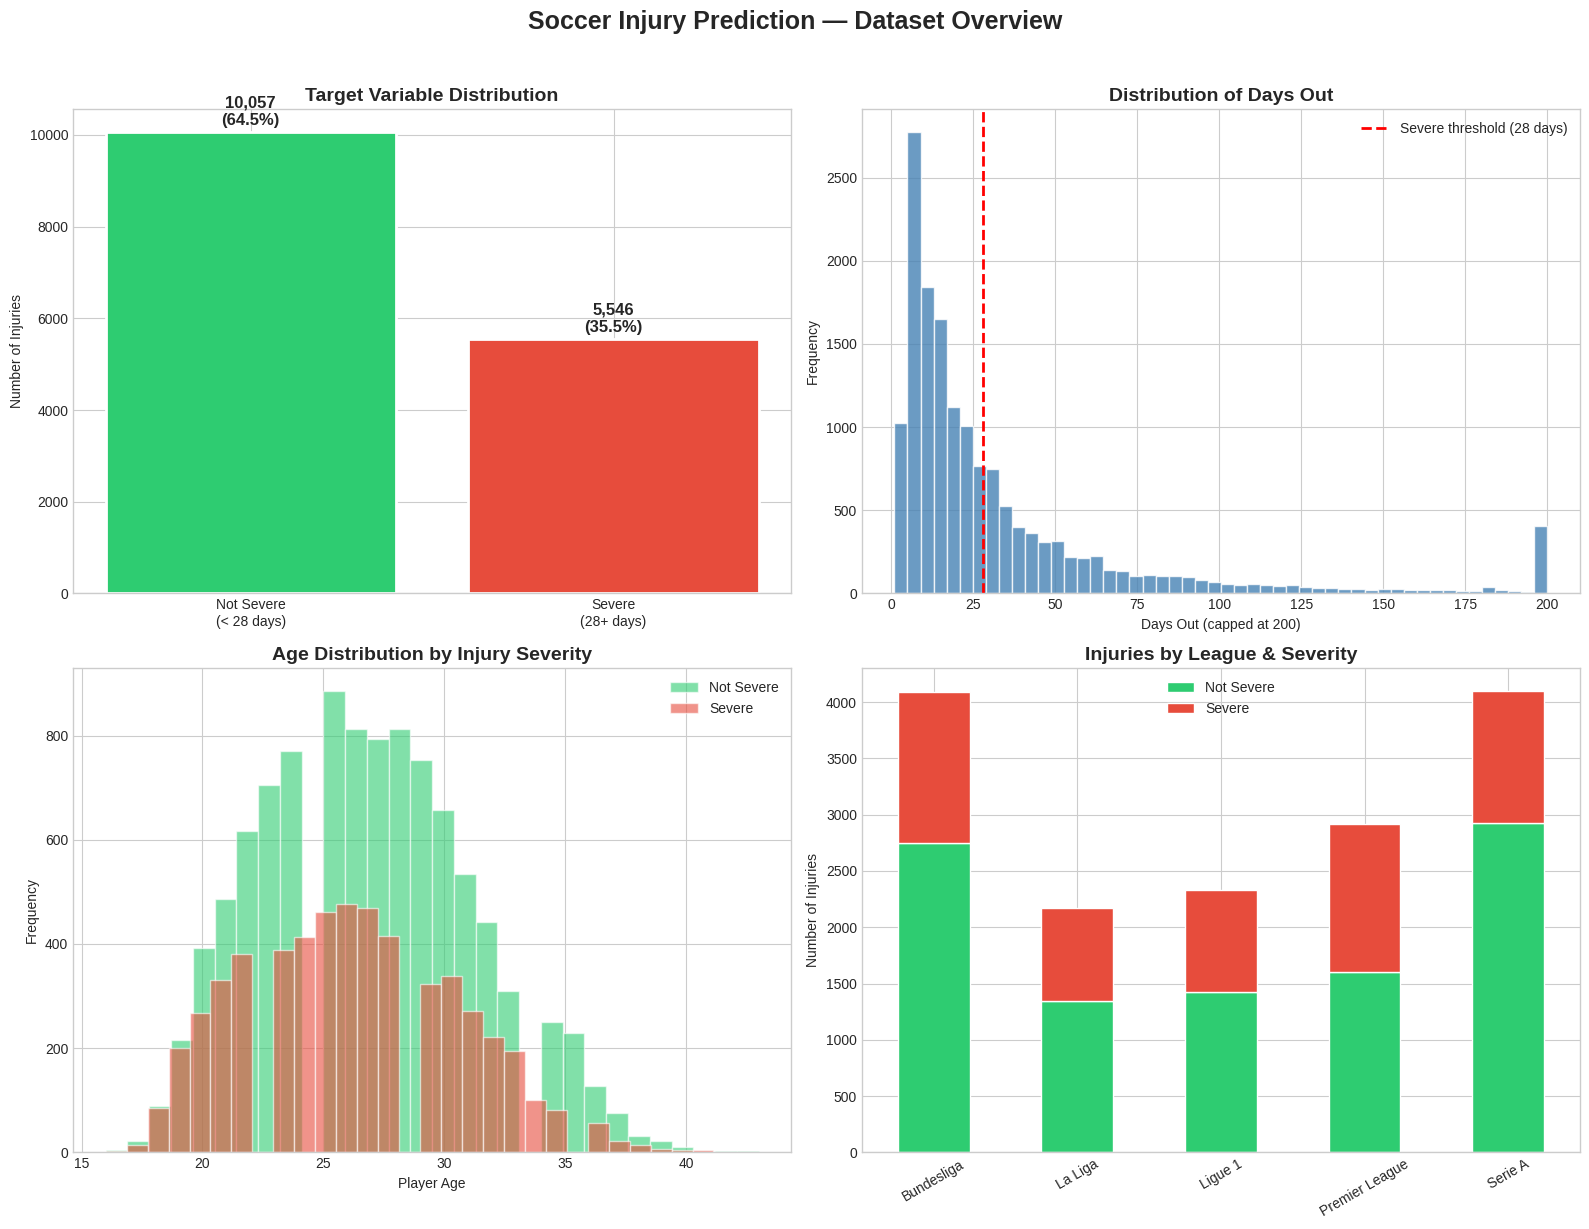

✅ Saved: eda_01_overview.png


In [14]:
# ============================================
# PHASE 3: EDA — Target Variable & Overview
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Soccer Injury Prediction — Dataset Overview', fontsize=18, fontweight='bold', y=1.02)

# 1. Target Distribution
colors = ['#2ecc71', '#e74c3c']
counts = df_merged['severe_injury'].value_counts()
bars = axes[0, 0].bar(['Not Severe\n(< 28 days)', 'Severe\n(28+ days)'], counts.values,
                      color=colors, edgecolor='white', linewidth=2)
axes[0, 0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Number of Injuries')
for bar, count in zip(bars, counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                    f'{count:,}\n({count/len(df_merged)*100:.1f}%)',
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

# 2. Days Out Distribution
axes[0, 1].hist(df_merged['days_numeric'].clip(upper=200), bins=50,
                color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(x=28, color='red', linestyle='--', linewidth=2, label='Severe threshold (28 days)')
axes[0, 1].set_title('Distribution of Days Out', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Days Out (capped at 200)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend(fontsize=10)

# 3. Age Distribution by Severity
for severity, color, label in [(0, '#2ecc71', 'Not Severe'), (1, '#e74c3c', 'Severe')]:
    subset = df_merged[df_merged['severe_injury'] == severity]['player_age']
    axes[1, 0].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1, 0].set_title('Age Distribution by Injury Severity', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Player Age')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend(fontsize=10)

# 4. Injuries by League
league_data = df_merged.groupby('league')['severe_injury'].value_counts().unstack(fill_value=0)
league_data.plot(kind='bar', stacked=True, ax=axes[1, 1], color=colors, edgecolor='white')
axes[1, 1].set_title('Injuries by League & Severity', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Number of Injuries')
axes[1, 1].legend(['Not Severe', 'Severe'], fontsize=10)
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/content/eda_01_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_01_overview.png")


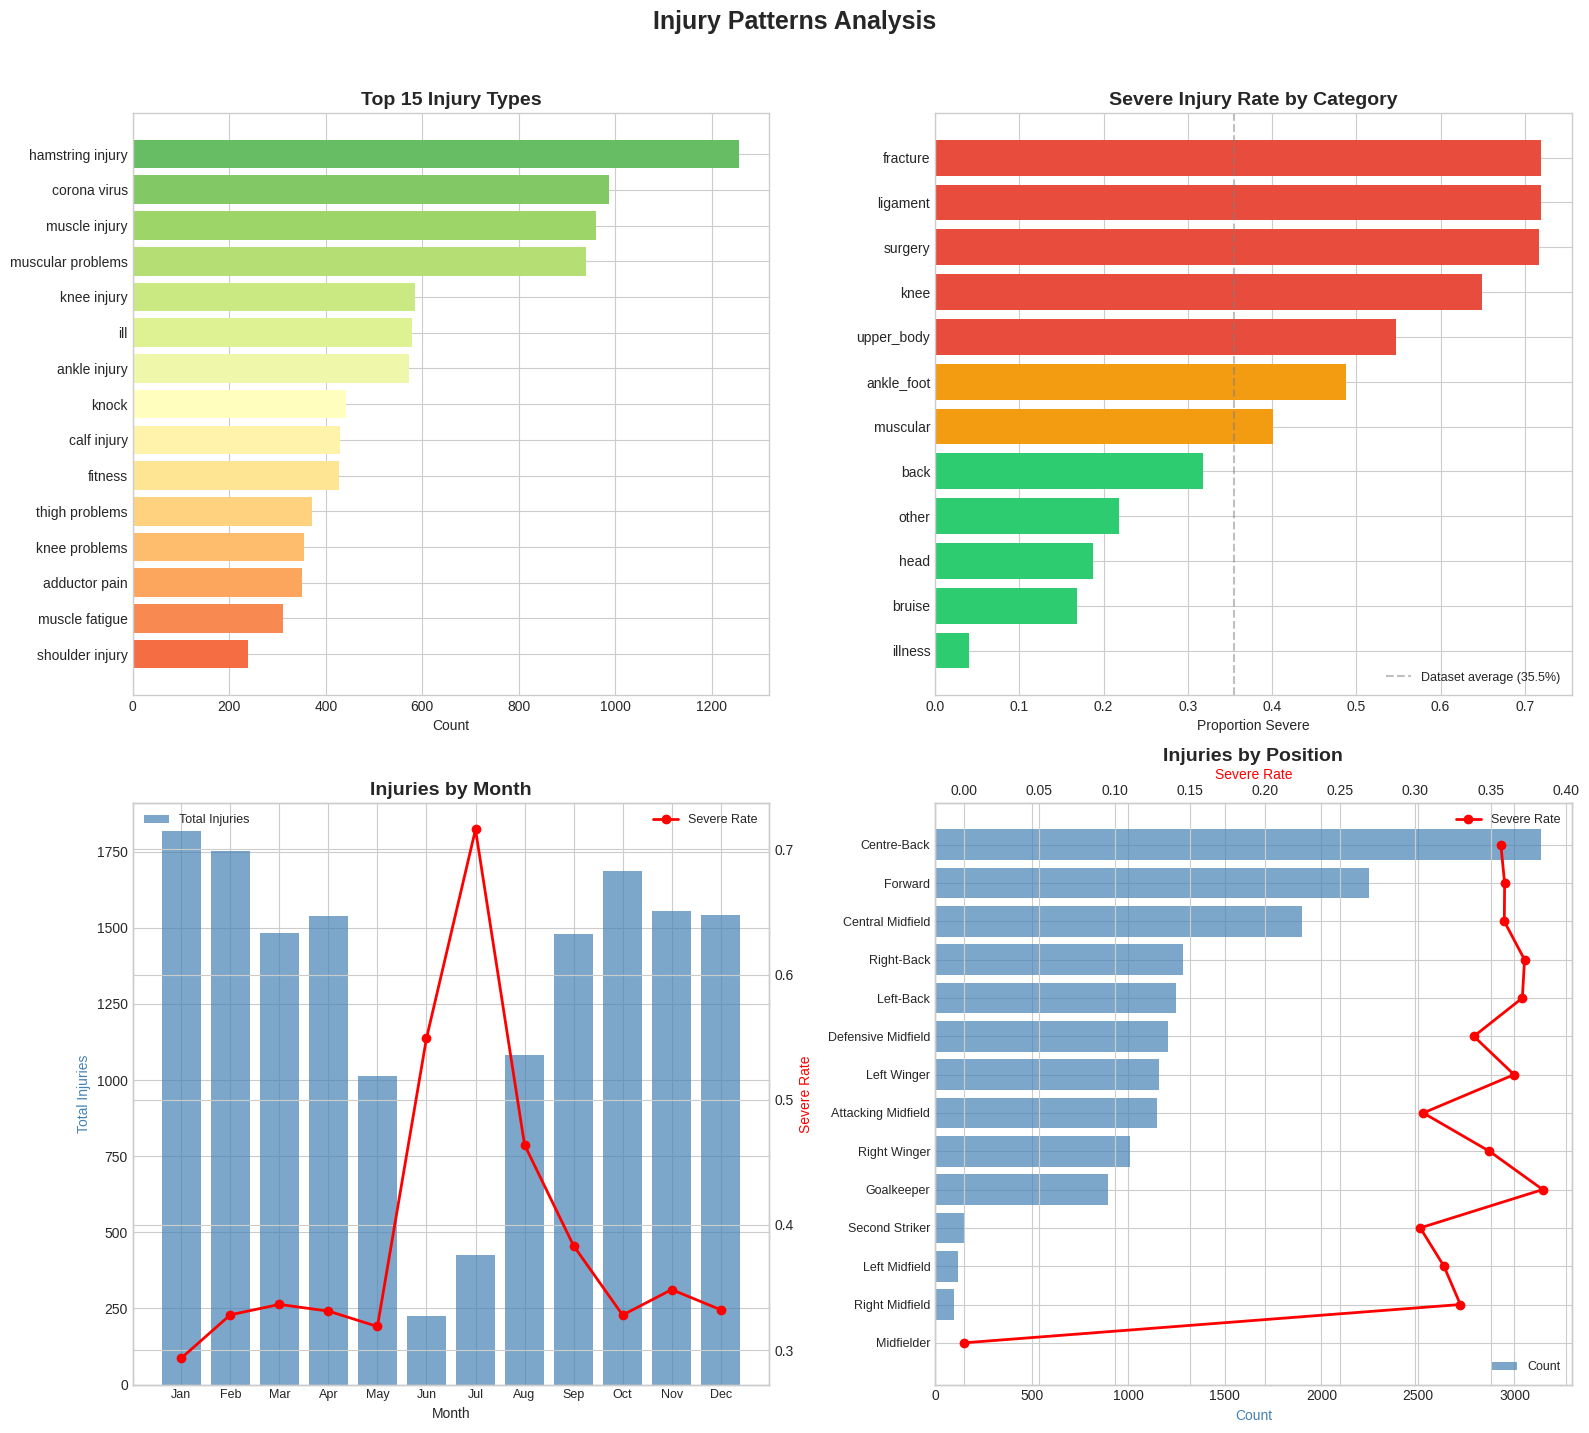

✅ Saved: eda_02_injury_patterns.png


In [15]:
# ============================================
# PHASE 3: EDA — Injury Patterns
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Injury Patterns Analysis', fontsize=18, fontweight='bold', y=1.02)

# 1. Top 15 Injury Types
top_injuries = df_merged['injury'].value_counts().head(15)
colors_gradient = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 15))
axes[0, 0].barh(range(len(top_injuries)), top_injuries.values, color=colors_gradient)
axes[0, 0].set_yticks(range(len(top_injuries)))
axes[0, 0].set_yticklabels(top_injuries.index, fontsize=10)
axes[0, 0].set_title('Top 15 Injury Types', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Count')
axes[0, 0].invert_yaxis()

# 2. Injury Category by Severity
cat_severity = df_merged.groupby('injury_category')['severe_injury'].mean().sort_values(ascending=True)
colors_bar = ['#e74c3c' if v > 0.5 else '#f39c12' if v > 0.35 else '#2ecc71' for v in cat_severity.values]
axes[0, 1].barh(range(len(cat_severity)), cat_severity.values, color=colors_bar)
axes[0, 1].set_yticks(range(len(cat_severity)))
axes[0, 1].set_yticklabels(cat_severity.index, fontsize=10)
axes[0, 1].set_title('Severe Injury Rate by Category', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Proportion Severe')
axes[0, 1].axvline(x=0.355, color='gray', linestyle='--', alpha=0.5, label='Dataset average (35.5%)')
axes[0, 1].legend(fontsize=9)

# 3. Monthly Injury Distribution
monthly = df_merged.groupby('injury_month').agg(
    total=('severe_injury', 'count'),
    severe=('severe_injury', 'sum')
).reset_index()
monthly['severe_rate'] = monthly['severe'] / monthly['total']

ax3 = axes[1, 0]
ax3_twin = ax3.twinx()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax3.bar(monthly['injury_month'], monthly['total'], color='steelblue', alpha=0.7, label='Total Injuries')
ax3_twin.plot(monthly['injury_month'], monthly['severe_rate'], color='red', marker='o', linewidth=2, label='Severe Rate')
ax3.set_title('Injuries by Month', fontsize=14, fontweight='bold')
ax3.set_xlabel('Month')
ax3.set_ylabel('Total Injuries', color='steelblue')
ax3_twin.set_ylabel('Severe Rate', color='red')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(month_names, fontsize=9)
ax3.legend(loc='upper left', fontsize=9)
ax3_twin.legend(loc='upper right', fontsize=9)

# 4. Position Analysis
pos_data = df_merged.groupby('player_position').agg(
    count=('severe_injury', 'count'),
    severe_rate=('severe_injury', 'mean')
).sort_values('count', ascending=True)

ax4 = axes[1, 1]
ax4_twin = ax4.twiny()          # FIX: twiny, not twinx — this is a horizontal bar chart
y_pos = range(len(pos_data))
ax4.barh(y_pos, pos_data['count'], color='steelblue', alpha=0.7, label='Count')
ax4_twin.plot(pos_data['severe_rate'], y_pos, color='red', marker='o', linewidth=2, label='Severe Rate')
ax4.set_yticks(y_pos)
ax4.set_yticklabels(pos_data.index, fontsize=9)
ax4.set_title('Injuries by Position', fontsize=14, fontweight='bold', pad=30)
ax4.set_xlabel('Count', color='steelblue')
ax4_twin.set_xlabel('Severe Rate', color='red')
ax4.legend(loc='lower right', fontsize=9)
ax4_twin.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('/content/eda_02_injury_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_02_injury_patterns.png")


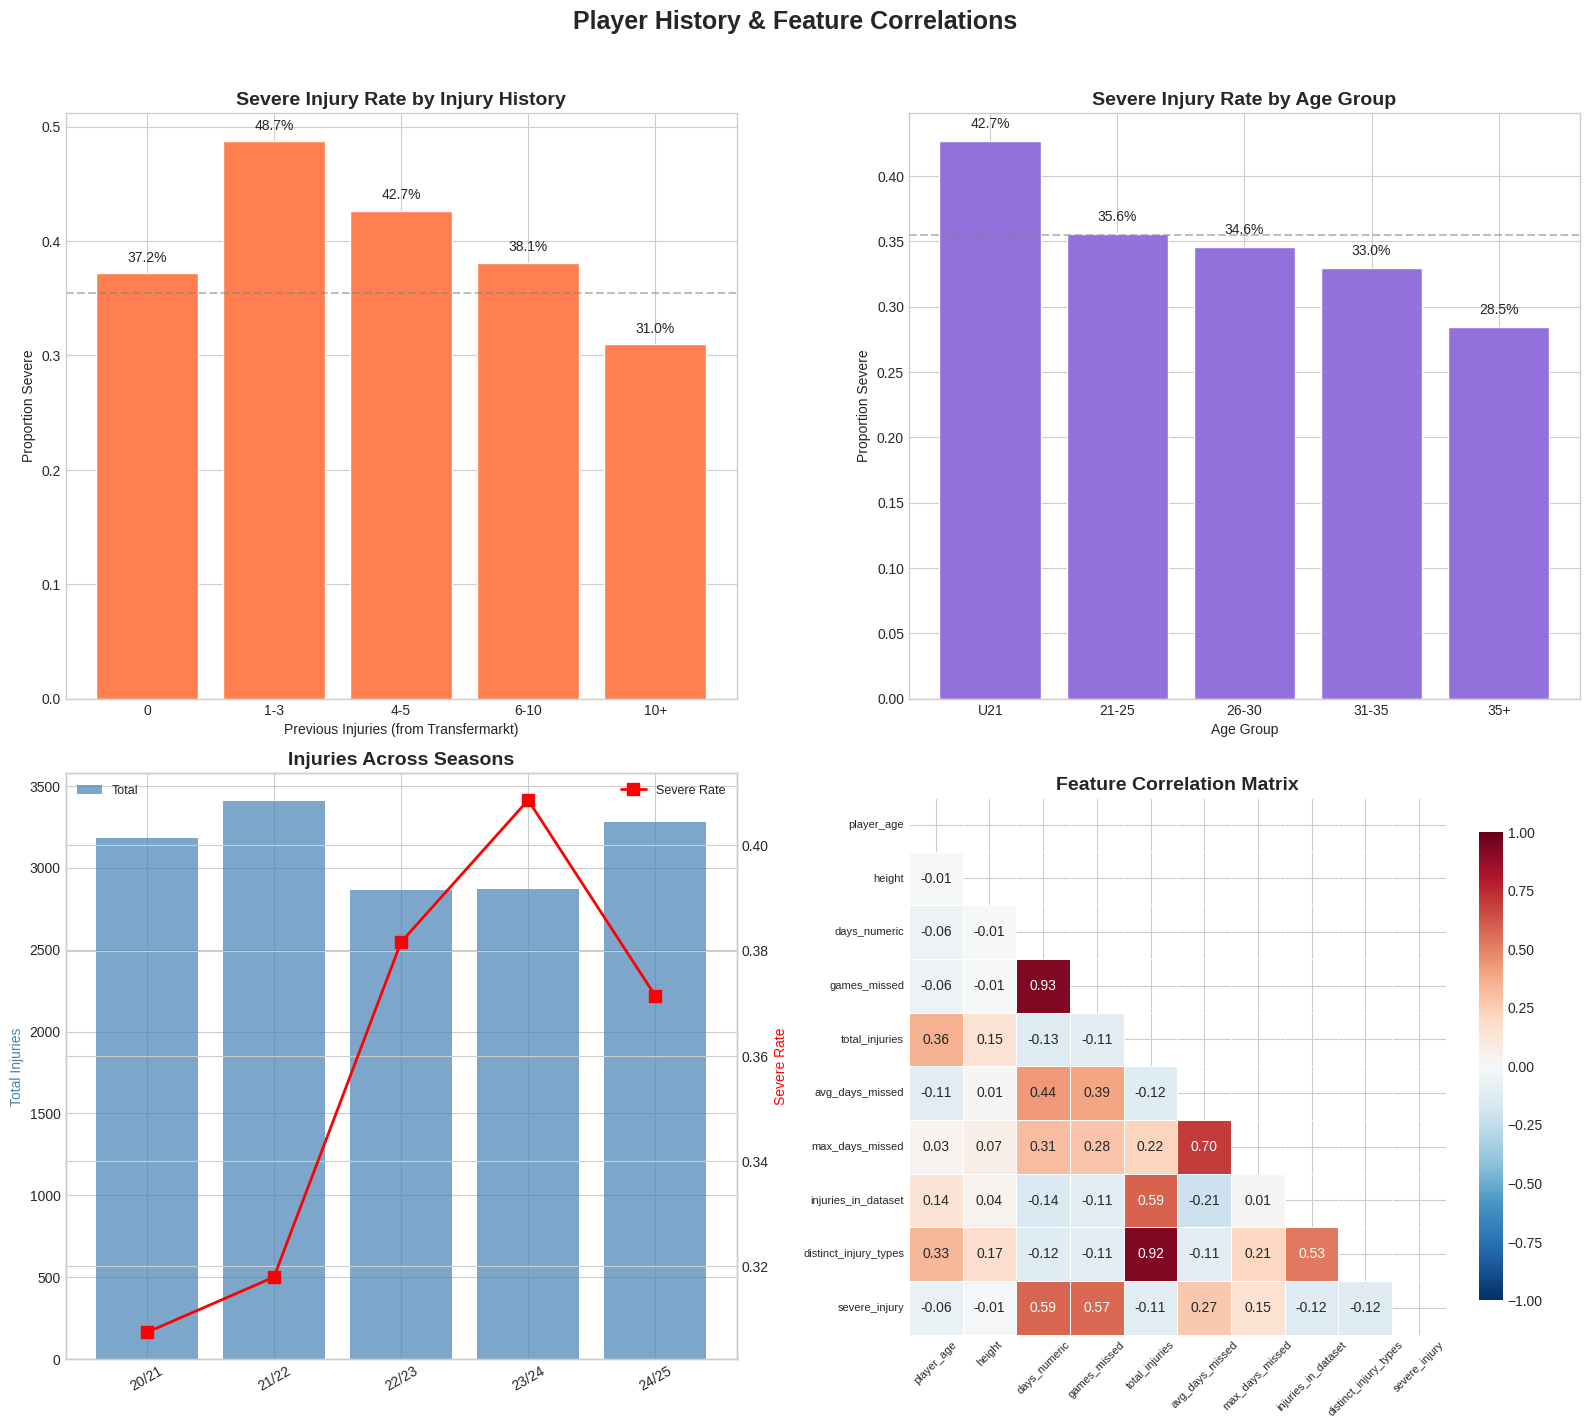

✅ Saved: eda_03_history_correlations.png


In [16]:
# ============================================
# PHASE 3: EDA — History Features & Correlations
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Player History & Feature Correlations', fontsize=18, fontweight='bold', y=1.02)

# 1. Injury History vs Severity
history_bins = [-1, 0, 3, 5, 10, 100]   # FIX: -1 lower edge so players with 0 injuries land in the '0' bin
history_labels = ['0', '1-3', '4-5', '6-10', '10+']
df_merged['history_bin'] = pd.cut(df_merged['total_injuries'], bins=history_bins, labels=history_labels)
history_severity = df_merged.groupby('history_bin', observed=True)['severe_injury'].mean()
axes[0, 0].bar(history_severity.index.astype(str), history_severity.values, color='coral', edgecolor='white')
axes[0, 0].set_title('Severe Injury Rate by Injury History', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Previous Injuries (from Transfermarkt)')
axes[0, 0].set_ylabel('Proportion Severe')
axes[0, 0].axhline(y=0.355, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(history_severity.values):
    axes[0, 0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)

# 2. Age Group vs Severity
age_severity = df_merged.groupby('age_group', observed=True)['severe_injury'].mean()
axes[0, 1].bar(age_severity.index.astype(str), age_severity.values, color='mediumpurple', edgecolor='white')
axes[0, 1].set_title('Severe Injury Rate by Age Group', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Age Group')
axes[0, 1].set_ylabel('Proportion Severe')
axes[0, 1].axhline(y=0.355, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(age_severity.values):
    axes[0, 1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)

# 3. Season Trends
season_col = df_merged.columns[0]
season_trend = df_merged.groupby(season_col).agg(
    total=('severe_injury', 'count'),
    severe=('severe_injury', 'sum'),
    severe_rate=('severe_injury', 'mean')
).reset_index()
ax3 = axes[1, 0]
ax3_twin = ax3.twinx()
ax3.bar(season_trend[season_col], season_trend['total'], color='steelblue', alpha=0.7, label='Total')
ax3_twin.plot(season_trend[season_col], season_trend['severe_rate'], color='red', marker='s', linewidth=2, markersize=8, label='Severe Rate')
ax3.set_title('Injuries Across Seasons', fontsize=14, fontweight='bold')
ax3.set_ylabel('Total Injuries', color='steelblue')
ax3_twin.set_ylabel('Severe Rate', color='red')
ax3.legend(loc='upper left', fontsize=9)
ax3_twin.legend(loc='upper right', fontsize=9)
ax3.tick_params(axis='x', rotation=30)

# 4. Correlation Heatmap
numeric_features = ['player_age', 'height', 'days_numeric', 'games_missed',
                    'total_injuries', 'avg_days_missed', 'max_days_missed',
                    'injuries_in_dataset', 'distinct_injury_types', 'severe_injury']
corr_matrix = df_merged[numeric_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1, 1], square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            vmin=-1, vmax=1)
axes[1, 1].set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1, 1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('/content/eda_03_history_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_03_history_correlations.png")


In [17]:
# ============================================
# PHASE 3: EDA — Statistical Tests
# ============================================

from scipy import stats

print("=" * 70)
print("📊 STATISTICAL TESTS")
print("=" * 70)

# 1. T-test: Age difference between severe and non-severe
severe_ages = df_merged[df_merged['severe_injury'] == 1]['player_age']
not_severe_ages = df_merged[df_merged['severe_injury'] == 0]['player_age']
t_stat, t_pval = stats.ttest_ind(severe_ages, not_severe_ages)
print(f"\n1️⃣ T-Test: Player Age vs Severity")
print(f"   Severe mean age: {severe_ages.mean():.2f}")
print(f"   Not severe mean age: {not_severe_ages.mean():.2f}")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {t_pval:.6f}")
print(f"   {'✅ Significant (p < 0.05)' if t_pval < 0.05 else '❌ Not significant'}")

# 2. Chi-square: Position vs Severity
contingency = pd.crosstab(df_merged['player_position'], df_merged['severe_injury'])
chi2, chi_pval, dof, expected = stats.chi2_contingency(contingency)
print(f"\n2️⃣ Chi-Square Test: Position vs Severity")
print(f"   Chi-square statistic: {chi2:.4f}")
print(f"   p-value: {chi_pval:.6f}")
print(f"   Degrees of freedom: {dof}")
print(f"   {'✅ Significant — position affects severity' if chi_pval < 0.05 else '❌ Not significant'}")

# 3. Chi-square: League vs Severity
contingency2 = pd.crosstab(df_merged['league'], df_merged['severe_injury'])
chi2_2, chi_pval_2, dof_2, _ = stats.chi2_contingency(contingency2)
print(f"\n3️⃣ Chi-Square Test: League vs Severity")
print(f"   Chi-square statistic: {chi2_2:.4f}")
print(f"   p-value: {chi_pval_2:.6f}")
print(f"   {'✅ Significant — league affects severity' if chi_pval_2 < 0.05 else '❌ Not significant'}")

# 4. Chi-square: Injury Category vs Severity
contingency3 = pd.crosstab(df_merged['injury_category'], df_merged['severe_injury'])
chi2_3, chi_pval_3, dof_3, _ = stats.chi2_contingency(contingency3)
print(f"\n4️⃣ Chi-Square Test: Injury Category vs Severity")
print(f"   Chi-square statistic: {chi2_3:.4f}")
print(f"   p-value: {chi_pval_3:.6f}")
print(f"   {'✅ Significant — injury type affects severity' if chi_pval_3 < 0.05 else '❌ Not significant'}")

# 5. Mann-Whitney U: Injury history vs severity
severe_history = df_merged[df_merged['severe_injury'] == 1]['total_injuries']
not_severe_history = df_merged[df_merged['severe_injury'] == 0]['total_injuries']
u_stat, u_pval = stats.mannwhitneyu(severe_history, not_severe_history, alternative='two-sided')
print(f"\n5️⃣ Mann-Whitney U: Injury History vs Severity")
print(f"   Severe median injuries: {severe_history.median():.1f}")
print(f"   Not severe median injuries: {not_severe_history.median():.1f}")
print(f"   U-statistic: {u_stat:.0f}")
print(f"   p-value: {u_pval:.6f}")
print(f"   {'✅ Significant' if u_pval < 0.05 else '❌ Not significant'}")


📊 STATISTICAL TESTS

1️⃣ T-Test: Player Age vs Severity
   Severe mean age: 26.17
   Not severe mean age: 26.76
   t-statistic: -8.0326
   p-value: 0.000000
   ✅ Significant (p < 0.05)

2️⃣ Chi-Square Test: Position vs Severity
   Chi-square statistic: 24.7355
   p-value: 0.025001
   Degrees of freedom: 13
   ✅ Significant — position affects severity

3️⃣ Chi-Square Test: League vs Severity
   Chi-square statistic: 235.7175
   p-value: 0.000000
   ✅ Significant — league affects severity

4️⃣ Chi-Square Test: Injury Category vs Severity
   Chi-square statistic: 2165.6110
   p-value: 0.000000
   ✅ Significant — injury type affects severity

5️⃣ Mann-Whitney U: Injury History vs Severity
   Severe median injuries: 10.0
   Not severe median injuries: 12.0
   U-statistic: 24130570
   p-value: 0.000000
   ✅ Significant


In [31]:
# ============================================
# PHASE 3: EDA — Key Insights Summary
# ============================================

print("=" * 70)
print("🔑 TOP 10 EDA INSIGHTS FOR THE REPORT")
print("=" * 70)

# Calculate key stats
most_common = df_merged['injury'].value_counts().index[0]
most_common_count = df_merged['injury'].value_counts().values[0]
highest_severe_cat = df_merged.groupby('injury_category')['severe_injury'].mean().idxmax()
highest_severe_cat_rate = df_merged.groupby('injury_category')['severe_injury'].mean().max()
riskiest_position = df_merged.groupby('player_position')['severe_injury'].mean().idxmax()
riskiest_pos_rate = df_merged.groupby('player_position')['severe_injury'].mean().max()
riskiest_league = df_merged.groupby('league')['severe_injury'].mean().idxmax()
riskiest_league_rate = df_merged.groupby('league')['severe_injury'].mean().max()
peak_month = df_merged.groupby('injury_month')['severe_injury'].count().idxmax()

insights = [
    f"1. DATASET SCOPE: {len(df_merged):,} injuries across {df_merged['league'].nunique()} European leagues, {df_merged[df_merged.columns[0]].nunique()} seasons (2020-2025)",
    f"2. TARGET SPLIT: 35.5% severe (28+ days) vs 64.5% not severe — a 1.8:1 ratio",
    f"3. MOST COMMON INJURY: '{most_common}' with {most_common_count:,} occurrences",
    f"4. HIGHEST SEVERITY CATEGORY: '{highest_severe_cat}' — {highest_severe_cat_rate:.1%} of these are severe",
    f"5. RISKIEST POSITION: '{riskiest_position}' — {riskiest_pos_rate:.1%} severe rate",
    f"6. RISKIEST LEAGUE: '{riskiest_league}' — {riskiest_league_rate:.1%} severe rate",
    f"7. PEAK INJURY MONTH: Month {peak_month} has the highest injury count",
    f"8. AGE EFFECT: Mean age for severe injuries = {severe_ages.mean():.1f} vs not severe = {not_severe_ages.mean():.1f} (p={t_pval:.4f})",
    # FIX: direction must come from the MEDIANS, not the p-value. A p-value says
    # whether a difference exists, never which way it points — the old line printed
    # "higher" whenever the test was significant, regardless of the actual direction.
    f"9. INJURY HISTORY: Players with more prior injuries show "
    f"{'HIGHER' if severe_history.median() > not_severe_history.median() else 'LOWER' if severe_history.median() < not_severe_history.median() else 'SIMILAR'} "
    f"severe rates — median {severe_history.median():.0f} prior injuries for severe "
    f"vs {not_severe_history.median():.0f} for non-severe (Mann-Whitney p={u_pval:.4f})",
    f"10. POSITION MATTERS: Chi-square confirms position significantly impacts severity (p={chi_pval:.6f})",
]

for insight in insights:
    print(f"\n   {insight}")

# Correlation with target
print(f"\n\n📊 TOP FEATURES CORRELATED WITH SEVERE INJURY:")
target_corr = df_merged[numeric_features].corr()['severe_injury'].drop('severe_injury').abs().sort_values(ascending=False)
for feat, corr in target_corr.head(8).items():
    print(f"   {feat}: {corr:.3f}")

print("\n\n" + "=" * 70)
print("✅ PHASE 3 COMPLETE — EDA analysis done")
print("=" * 70)
print("📄 Charts saved: eda_01_overview.png, eda_02_injury_patterns.png, eda_03_history_correlations.png")
print("🎯 Next: Phase 4 — Assumptions Document")


🔑 TOP 10 EDA INSIGHTS FOR THE REPORT

   1. DATASET SCOPE: 15,603 injuries across 5 European leagues, 5 seasons (2020-2025)

   2. TARGET SPLIT: 35.5% severe (28+ days) vs 64.5% not severe — a 1.8:1 ratio

   3. MOST COMMON INJURY: 'hamstring injury' with 1,256 occurrences

   4. HIGHEST SEVERITY CATEGORY: 'fracture' — 72.0% of these are severe

   5. RISKIEST POSITION: 'Goalkeeper' — 38.5% severe rate

   6. RISKIEST LEAGUE: 'Premier League' — 45.2% severe rate

   7. PEAK INJURY MONTH: Month 1 has the highest injury count

   8. AGE EFFECT: Mean age for severe injuries = 26.2 vs not severe = 26.8 (p=0.0000)

   9. INJURY HISTORY: Players with more prior injuries show LOWER severe rates — median 10 prior injuries for severe vs 12 for non-severe (Mann-Whitney p=0.0000)

   10. POSITION MATTERS: Chi-square confirms position significantly impacts severity (p=0.025001)


📊 TOP FEATURES CORRELATED WITH SEVERE INJURY:
   days_numeric: 0.585
   games_missed: 0.574
   avg_days_missed: 0.268
 

## Phase 4 — Assumptions & Diagnostics

In [19]:
# ============================================
# PHASE 4: Assumption Check 1 — Multicollinearity (VIF)
# ============================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

print("=" * 70)
print("📐 ASSUMPTION 1: NO SEVERE MULTICOLLINEARITY")
print("=" * 70)

def compute_vif(frame, cols):
    """VIF for each column. >10 = severe, 5-10 = moderate, <5 = acceptable."""
    X = add_constant(frame[cols].astype(float), has_constant='add')
    rows = []
    for i, c in enumerate(X.columns):
        if c == 'const':
            continue
        rows.append({'feature': c, 'VIF': variance_inflation_factor(X.values, i)})
    return pd.DataFrame(rows).sort_values('VIF', ascending=False).reset_index(drop=True)

vif_all = compute_vif(df_merged, FEATURE_COLS)
print(f"\n📊 VIF — all {len(FEATURE_COLS)} candidate features:")
display(vif_all)

severe_vif = vif_all[vif_all['VIF'] > 10]['feature'].tolist()
print(f"\n⚠️ Severe multicollinearity (VIF > 10): {severe_vif}")
print("   Interpretation: these carry near-duplicate information. Logistic Regression")
print("   coefficients become unstable and uninterpretable; tree models are unaffected.")


📐 ASSUMPTION 1: NO SEVERE MULTICOLLINEARITY

📊 VIF — all 18 candidate features:


,feature,VIF
0,age_squared,132.991
1,player_age,121.570
2,total_days_missed,11.228
3,total_injuries,9.767
4,distinct_injury_types,7.063
5,total_games_missed,6.311
6,max_days_missed,4.562
7,is_over_30,3.164
8,avg_days_missed,2.652
9,injuries_in_dataset,1.647



⚠️ Severe multicollinearity (VIF > 10): ['age_squared', 'player_age', 'total_days_missed']
   Interpretation: these carry near-duplicate information. Logistic Regression
   coefficients become unstable and uninterpretable; tree models are unaffected.


In [20]:
# ============================================
# PHASE 4: Assumption Check 2 — Target Leakage Audit
# ============================================

print("=" * 70)
print("🚨 ASSUMPTION 2: NO TARGET LEAKAGE")
print("=" * 70)

# A feature leaks if it is derived from, or is a consequence of, the outcome.
leak_audit = {
    'days_numeric': 'DEFINITIONAL — severe_injury IS (days_numeric >= 28)',
    'games_missed': 'CONSEQUENCE — games missed because of this injury, unknown at prediction time',
    'position_risk_rate': 'FITTED ON FULL DATA — encodes test-set outcomes into a training feature',
    'league_risk_rate': 'FITTED ON FULL DATA — encodes test-set outcomes into a training feature',
}

print("\n📋 Flagged features:")
for f, why in leak_audit.items():
    if f in df_merged.columns:
        c = df_merged[f].corr(df_merged['severe_injury']) if df_merged[f].dtype != 'O' else float('nan')
        print(f"\n   ❌ {f}")
        print(f"      reason      : {why}")
        print(f"      corr target : {c:.3f}")

# Evidence: days_numeric and games_missed are near-duplicates of each other
dup = df_merged['days_numeric'].corr(df_merged['games_missed'])
print(f"\n🔍 corr(days_numeric, games_missed) = {dup:.3f}")
print("   Two near-identical restatements of injury duration — the thing being predicted.")

# --- Build the clean modelling feature set ---
LEAKY = [f for f in leak_audit if f in FEATURE_COLS]
COLLINEAR_DROP = ['age_squared']   # VIF > 100 against player_age; adds no signal

MODEL_FEATURES = [f for f in FEATURE_COLS if f not in LEAKY + COLLINEAR_DROP]

print(f"\n{'='*70}")
print("✅ FINAL MODELLING FEATURE SET")
print("=" * 70)
print(f"\n   Dropped for leakage ({len(LEAKY)}): {LEAKY}")
print(f"   Dropped for collinearity ({len(COLLINEAR_DROP)}): {COLLINEAR_DROP}")
print(f"\n   Retained numeric features ({len(MODEL_FEATURES)}):")
for f in MODEL_FEATURES:
    print(f"      • {f}")
print(f"\n   Categorical features ({len(CAT_FEATURES)}): {CAT_FEATURES}")

# Re-check VIF on the clean set
vif_clean = compute_vif(df_merged, MODEL_FEATURES)
print(f"\n📊 VIF after cleaning (max = {vif_clean['VIF'].max():.2f}):")
display(vif_clean)

# Honest correlation ceiling now that leakage is gone
clean_corr = df_merged[MODEL_FEATURES + ['severe_injury']].corr()['severe_injury'].drop('severe_injury').abs().sort_values(ascending=False)
print(f"\n📉 Strongest remaining correlation with target: {clean_corr.iloc[0]:.3f} ({clean_corr.index[0]})")
print("   This is the honest signal ceiling the Phase 5 models must beat.")


🚨 ASSUMPTION 2: NO TARGET LEAKAGE

📋 Flagged features:

   ❌ days_numeric
      reason      : DEFINITIONAL — severe_injury IS (days_numeric >= 28)
      corr target : 0.585

   ❌ games_missed
      reason      : CONSEQUENCE — games missed because of this injury, unknown at prediction time
      corr target : 0.574

   ❌ position_risk_rate
      reason      : FITTED ON FULL DATA — encodes test-set outcomes into a training feature
      corr target : 0.040

   ❌ league_risk_rate
      reason      : FITTED ON FULL DATA — encodes test-set outcomes into a training feature
      corr target : 0.123

🔍 corr(days_numeric, games_missed) = 0.935
   Two near-identical restatements of injury duration — the thing being predicted.

✅ FINAL MODELLING FEATURE SET

   Dropped for leakage (3): ['games_missed', 'position_risk_rate', 'league_risk_rate']
   Dropped for collinearity (1): ['age_squared']

   Retained numeric features (14):
      • player_age
      • is_over_30
      • height
      • is_muscu

,feature,VIF
0,total_days_missed,11.074
1,total_injuries,9.731
2,distinct_injury_types,7.003
3,total_games_missed,6.002
4,max_days_missed,4.548
5,player_age,2.742
6,avg_days_missed,2.544
7,is_over_30,2.502
8,injuries_in_dataset,1.645
9,is_muscular,1.172



📉 Strongest remaining correlation with target: 0.268 (avg_days_missed)
   This is the honest signal ceiling the Phase 5 models must beat.


📈 ASSUMPTION 3: LINEARITY OF THE LOGIT (Logistic Regression only)

   Logistic Regression assumes each continuous predictor is linear in log-odds.
   Random Forest and XGBoost make no such assumption — this check scopes
   which model the caveat applies to, it does not disqualify the others.



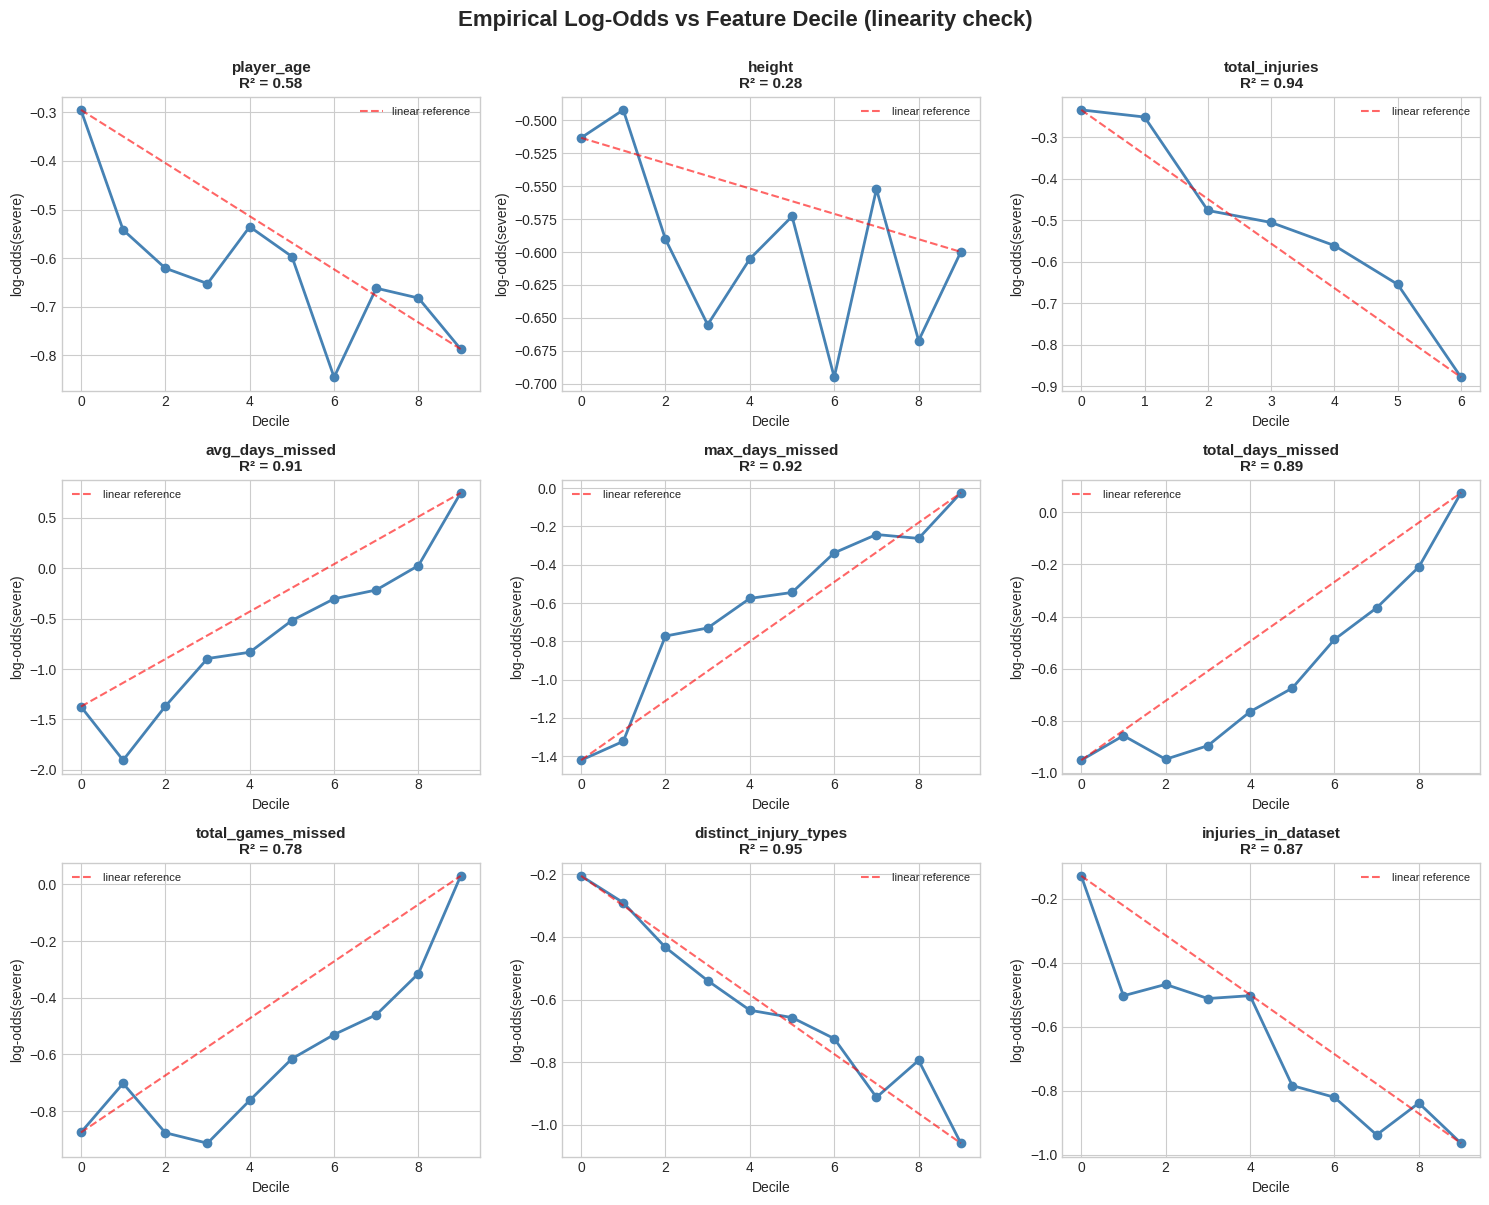


📊 Linearity of the logit by feature (R² of straight-line fit to decile log-odds):


,feature,linearity_R2,verdict
1,height,0.284,NON-LINEAR
0,player_age,0.580,NON-LINEAR
6,total_games_missed,0.778,NON-LINEAR
8,injuries_in_dataset,0.865,linear
5,total_days_missed,0.887,linear
3,avg_days_missed,0.911,linear
4,max_days_missed,0.915,linear
2,total_injuries,0.939,linear
7,distinct_injury_types,0.949,linear



⚠️ Non-linear in the logit: ['height', 'player_age', 'total_games_missed']
   → Logistic Regression will under-fit these; expect RF/XGBoost to outperform it.


📌 ASSUMPTION 4: OUTLIERS & INFLUENTIAL POINTS

   Rows beyond |z| > 4, by feature:
      avg_days_missed: 145 rows (0.93%)
      height: 131 rows (0.84%)
      max_days_missed: 95 rows (0.61%)
      total_days_missed: 88 rows (0.56%)
      total_games_missed: 69 rows (0.44%)

   Rows with at least one extreme value: 435 (2.79%)
   Decision: RETAINED. These are genuine long-duration injuries (ACL ruptures,
   fractures), not data errors — they are exactly the cases the model must catch.


🔗 ASSUMPTION 5: INDEPENDENCE OF OBSERVATIONS

   Rows (injuries): 15,603
   Unique players : 4,081
   Mean injuries per player: 3.82
   Max injuries for one player: 21

   ⚠️ VIOLATED: rows are not independent — the same player appears many times.
   Mitigation for Phase 5: use GroupShuffleSplit / StratifiedGroupKFold on
   player_name_clean so

In [21]:
# ============================================
# PHASE 4: Assumption Check 3 — Linearity of the Logit & Influence
# ============================================

print("=" * 70)
print("📈 ASSUMPTION 3: LINEARITY OF THE LOGIT (Logistic Regression only)")
print("=" * 70)
print("\n   Logistic Regression assumes each continuous predictor is linear in log-odds.")
print("   Random Forest and XGBoost make no such assumption — this check scopes")
print("   which model the caveat applies to, it does not disqualify the others.\n")

continuous = [f for f in MODEL_FEATURES
              if df_merged[f].nunique() > 10 and not f.startswith('is_')]

n = len(continuous)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
fig.suptitle('Empirical Log-Odds vs Feature Decile (linearity check)',
             fontsize=16, fontweight='bold', y=1.00)
axes = np.array(axes).reshape(-1)

linearity_report = []
for i, f in enumerate(continuous):
    ax = axes[i]
    # Bin into deciles, compute empirical log-odds per bin
    b = pd.qcut(df_merged[f], 10, duplicates='drop')
    g = df_merged.groupby(b, observed=True)['severe_injury'].agg(['mean', 'count'])
    p = g['mean'].clip(0.01, 0.99)
    logodds = np.log(p / (1 - p))
    xs = np.arange(len(logodds))
    ax.plot(xs, logodds.values, marker='o', color='steelblue', linewidth=2)
    # Straight-line reference through the endpoints
    ax.plot([xs[0], xs[-1]], [logodds.values[0], logodds.values[-1]],
            'r--', alpha=0.6, label='linear reference')
    # R² of a straight-line fit = how linear it is
    coef = np.polyfit(xs, logodds.values, 1)
    pred = np.polyval(coef, xs)
    ss_res = ((logodds.values - pred) ** 2).sum()
    ss_tot = ((logodds.values - logodds.values.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    linearity_report.append({'feature': f, 'linearity_R2': r2,
                             'verdict': 'linear' if r2 > 0.8 else 'NON-LINEAR'})
    ax.set_title(f'{f}\nR² = {r2:.2f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Decile')
    ax.set_ylabel('log-odds(severe)')
    ax.legend(fontsize=8)

for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('/content/phase4_linearity_check.png', dpi=150, bbox_inches='tight')
plt.show()

lin_df = pd.DataFrame(linearity_report).sort_values('linearity_R2')
print("\n📊 Linearity of the logit by feature (R² of straight-line fit to decile log-odds):")
display(lin_df)

nonlin = lin_df[lin_df['verdict'] == 'NON-LINEAR']['feature'].tolist()
print(f"\n⚠️ Non-linear in the logit: {nonlin if nonlin else 'none'}")
print("   → Logistic Regression will under-fit these; expect RF/XGBoost to outperform it.")

# --- Outliers / influence ---
print(f"\n\n{'='*70}")
print("📌 ASSUMPTION 4: OUTLIERS & INFLUENTIAL POINTS")
print("=" * 70)
z = (df_merged[MODEL_FEATURES] - df_merged[MODEL_FEATURES].mean()) / df_merged[MODEL_FEATURES].std()
extreme = (z.abs() > 4).sum().sort_values(ascending=False)
extreme = extreme[extreme > 0]
print(f"\n   Rows beyond |z| > 4, by feature:")
if len(extreme):
    for f, c in extreme.items():
        print(f"      {f}: {c} rows ({c/len(df_merged)*100:.2f}%)")
else:
    print("      none")
rows_affected = (z.abs() > 4).any(axis=1).sum()
print(f"\n   Rows with at least one extreme value: {rows_affected:,} ({rows_affected/len(df_merged)*100:.2f}%)")
print("   Decision: RETAINED. These are genuine long-duration injuries (ACL ruptures,")
print("   fractures), not data errors — they are exactly the cases the model must catch.")

# --- Independence ---
print(f"\n\n{'='*70}")
print("🔗 ASSUMPTION 5: INDEPENDENCE OF OBSERVATIONS")
print("=" * 70)
n_players = df_merged['player_name_clean'].nunique()
print(f"\n   Rows (injuries): {len(df_merged):,}")
print(f"   Unique players : {n_players:,}")
print(f"   Mean injuries per player: {len(df_merged)/n_players:.2f}")
print(f"   Max injuries for one player: {df_merged['injuries_in_dataset'].max():.0f}")
print("\n   ⚠️ VIOLATED: rows are not independent — the same player appears many times.")
print("   Mitigation for Phase 5: use GroupShuffleSplit / StratifiedGroupKFold on")
print("   player_name_clean so no player appears in both train and test.")


In [22]:
# ============================================
# PHASE 4: Assumptions Summary & Frozen Modelling Set
# ============================================

print("=" * 70)
print("📋 PHASE 4 — ASSUMPTIONS SUMMARY")
print("=" * 70)

summary = pd.DataFrame([
    {'#': 1, 'Assumption': 'No severe multicollinearity',
     'Status': 'RESOLVED',
     'Action': 'Dropped age_squared (VIF > 100 vs player_age)'},
    {'#': 2, 'Assumption': 'No target leakage',
     'Status': 'RESOLVED',
     'Action': f'Dropped {len(LEAKY)} leaking features: {", ".join(LEAKY)}'},
    {'#': 3, 'Assumption': 'Linearity of the logit',
     'Status': 'PARTIAL',
     'Action': 'Applies to Logistic Regression only; RF/XGBoost exempt'},
    {'#': 4, 'Assumption': 'No unduly influential outliers',
     'Status': 'ACCEPTED',
     'Action': 'Extreme durations retained — genuine severe injuries'},
    {'#': 5, 'Assumption': 'Independence of observations',
     'Status': 'VIOLATED',
     'Action': 'Group-aware CV on player_name_clean in Phase 5'},
    {'#': 6, 'Assumption': 'Balanced classes',
     'Status': 'MILD',
     'Action': '35.5/64.5 (1.8:1) — class_weight, not SMOTE'},
])
display(summary)

# --- Freeze the modelling frame ---
model_df = df_merged[MODEL_FEATURES + CAT_FEATURES + ['severe_injury', 'player_name_clean']].copy()
model_df.to_csv('/content/phase4_model_ready.csv', index=False)

print(f"\n💾 Saved: phase4_model_ready.csv  ({model_df.shape[0]:,} rows × {model_df.shape[1]} columns)")
print(f"\n   MODEL_FEATURES ({len(MODEL_FEATURES)}) — numeric, leakage-free")
print(f"   CAT_FEATURES   ({len(CAT_FEATURES)}) — to encode in Phase 5")
print(f"   GROUP_COL      = 'player_name_clean' — for group-aware splitting")
print(f"   TARGET         = 'severe_injury'")

GROUP_COL = 'player_name_clean'

print("\n\n" + "=" * 70)
print("✅ PHASE 4 COMPLETE — Assumptions documented, feature set frozen")
print("=" * 70)
print("🎯 Next: Phase 5 — Modeling (LogReg → Random Forest → XGBoost)")


📋 PHASE 4 — ASSUMPTIONS SUMMARY


,#,Assumption,Status,Action
0,1,No severe multicollinearity,RESOLVED,Dropped age_squared (VIF > 100 vs player_age)
1,2,No target leakage,RESOLVED,"Dropped 3 leaking features: games_missed, posi..."
2,3,Linearity of the logit,PARTIAL,Applies to Logistic Regression only; RF/XGBoos...
3,4,No unduly influential outliers,ACCEPTED,Extreme durations retained — genuine severe in...
4,5,Independence of observations,VIOLATED,Group-aware CV on player_name_clean in Phase 5
5,6,Balanced classes,MILD,"35.5/64.5 (1.8:1) — class_weight, not SMOTE"



💾 Saved: phase4_model_ready.csv  (15,603 rows × 22 columns)

   MODEL_FEATURES (14) — numeric, leakage-free
   CAT_FEATURES   (6) — to encode in Phase 5
   GROUP_COL      = 'player_name_clean' — for group-aware splitting
   TARGET         = 'severe_injury'


✅ PHASE 4 COMPLETE — Assumptions documented, feature set frozen
🎯 Next: Phase 5 — Modeling (LogReg → Random Forest → XGBoost)


## Phase 5 — Modelling: Logistic Regression → Random Forest → XGBoost

In [23]:
# ============================================
# PHASE 5: Modelling Prep — Encode & Split by Player
# ============================================

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold

print("=" * 70)
print("🔧 PHASE 5 PREP — ENCODING & GROUP-AWARE SPLIT")
print("=" * 70)

# --- Drop the last feature above the VIF threshold (Phase 4, §5.1) ---
DROP_VIF = ['total_days_missed']          # VIF 11.07; ≈ total_injuries × avg_days_missed
MODEL_FEATURES = [f for f in MODEL_FEATURES if f not in DROP_VIF]
print(f"\n✂️  Dropped for collinearity: {DROP_VIF}")
print(f"   Numeric features now: {len(MODEL_FEATURES)}")

# --- One-hot encode the categoricals ---
X_num = df_merged[MODEL_FEATURES].reset_index(drop=True).astype(float)
X_cat = pd.get_dummies(df_merged[CAT_FEATURES].astype(str),
                       prefix=CAT_FEATURES, drop_first=True).reset_index(drop=True).astype(float)
X = pd.concat([X_num, X_cat], axis=1)
y = df_merged[TARGET].reset_index(drop=True)
groups = df_merged[GROUP_COL].reset_index(drop=True)

print(f"\n📐 Design matrix: {X.shape[0]:,} rows × {X.shape[1]} columns")
print(f"   {len(MODEL_FEATURES)} numeric + {X_cat.shape[1]} one-hot dummies")

# --- Group-aware holdout split: no player in both train and test ---
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

overlap = set(g_train) & set(g_test)
print(f"\n🔒 Split integrity check:")
print(f"   Train: {len(X_train):,} rows / {g_train.nunique():,} players  —  severe rate {y_train.mean():.1%}")
print(f"   Test : {len(X_test):,} rows / {g_test.nunique():,} players  —  severe rate {y_test.mean():.1%}")
print(f"   Players in BOTH train and test: {len(overlap)}")
assert len(overlap) == 0, "Player leakage across the split!"
print("   ✅ No player appears on both sides — Phase 4 assumption 5 respected.")

# --- Shared CV object for every GridSearch below ---
cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Imbalance weight for XGBoost
SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\n⚖️  scale_pos_weight for XGBoost: {SCALE_POS_WEIGHT:.3f}")

results = []   # each model appends its metrics dict here


🔧 PHASE 5 PREP — ENCODING & GROUP-AWARE SPLIT

✂️  Dropped for collinearity: ['total_days_missed']
   Numeric features now: 13

📐 Design matrix: 15,603 rows × 51 columns
   13 numeric + 38 one-hot dummies

🔒 Split integrity check:
   Train: 11,697 rows / 3,060 players  —  severe rate 35.7%
   Test : 3,906 rows / 1,021 players  —  severe rate 35.0%
   Players in BOTH train and test: 0
   ✅ No player appears on both sides — Phase 4 assumption 5 respected.

⚖️  scale_pos_weight for XGBoost: 1.800


1️⃣  LOGISTIC REGRESSION

🔍 Best params : {'clf__C': 10.0}
   CV ROC-AUC  : 0.7819


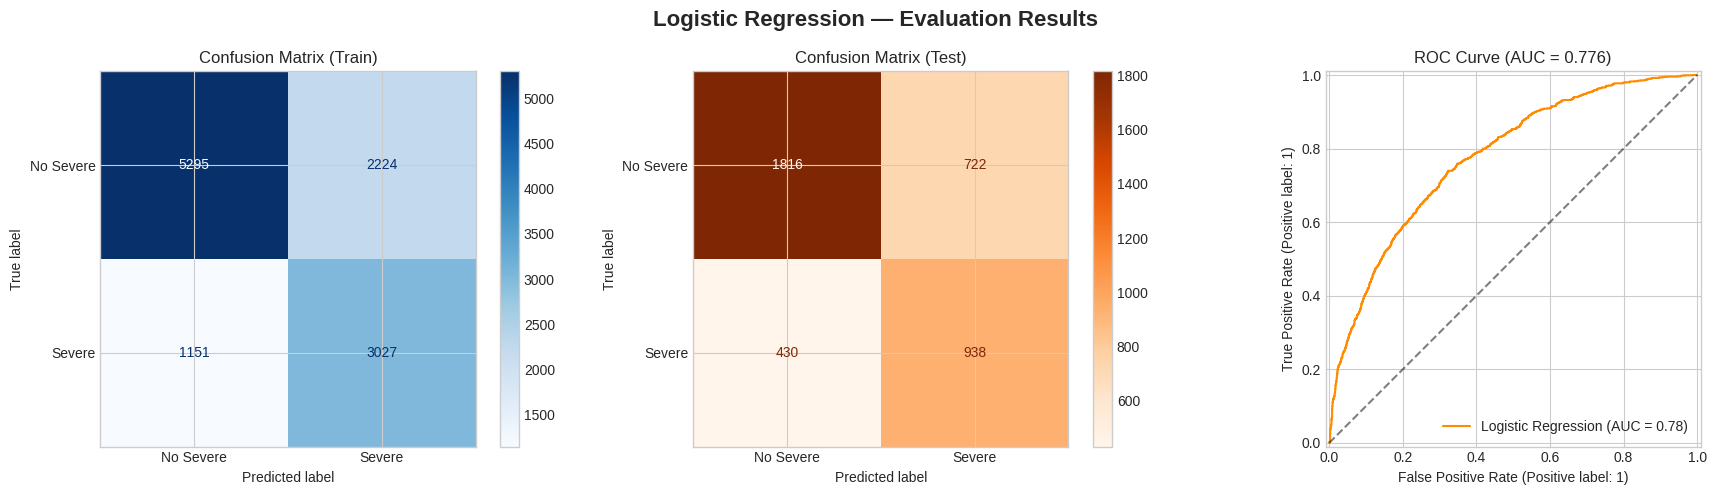


Logistic Regression — TRAIN Classification Report
              precision    recall  f1-score   support

   No Severe       0.82      0.70      0.76      7519
      Severe       0.58      0.72      0.64      4178

    accuracy                           0.71     11697
   macro avg       0.70      0.71      0.70     11697
weighted avg       0.73      0.71      0.72     11697


Logistic Regression — TEST Classification Report
              precision    recall  f1-score   support

   No Severe       0.81      0.72      0.76      2538
      Severe       0.57      0.69      0.62      1368

    accuracy                           0.71      3906
   macro avg       0.69      0.70      0.69      3906
weighted avg       0.72      0.71      0.71      3906


📊 Top 15 coefficients (standardised — sign shows direction of risk):


,feature,coefficient
7,avg_days_missed,0.894
38,injury_category_other,-0.507
5,is_illness,-0.468
34,injury_category_illness,-0.468
8,max_days_missed,-0.410
9,total_games_missed,0.392
31,injury_category_bruise,-0.324
0,player_age,-0.310
45,age_group_31-35,0.203
44,age_group_26-30,0.189


In [24]:
# ============================================
# PHASE 5: Model 1 — Logistic Regression
# ============================================

print("=" * 70)
print("1️⃣  LOGISTIC REGRESSION")
print("=" * 70)

pipe_lr = ImbPipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                               solver='liblinear', random_state=RANDOM_STATE)),
])

grid_lr = {'clf__C': [0.01, 0.1, 1.0, 10.0]}

gs_lr = GridSearchCV(pipe_lr, grid_lr, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
gs_lr.fit(X_train, y_train, groups=g_train)

print(f"\n🔍 Best params : {gs_lr.best_params_}")
print(f"   CV ROC-AUC  : {gs_lr.best_score_:.4f}")

lr_model = gs_lr.best_estimator_
results.append(evaluate_model(lr_model, X_train, X_test, y_train, y_test, 'Logistic Regression'))

# --- Coefficients (scaled, so directly comparable) ---
coefs = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_model.named_steps['clf'].coef_[0],
}).assign(abs_coef=lambda d: d['coefficient'].abs()).sort_values('abs_coef', ascending=False)

print("\n📊 Top 15 coefficients (standardised — sign shows direction of risk):")
display(coefs.head(15)[['feature', 'coefficient']])


2️⃣  RANDOM FOREST

🔍 Best params : {'max_depth': None, 'min_samples_leaf': 5}
   CV ROC-AUC  : 0.7901


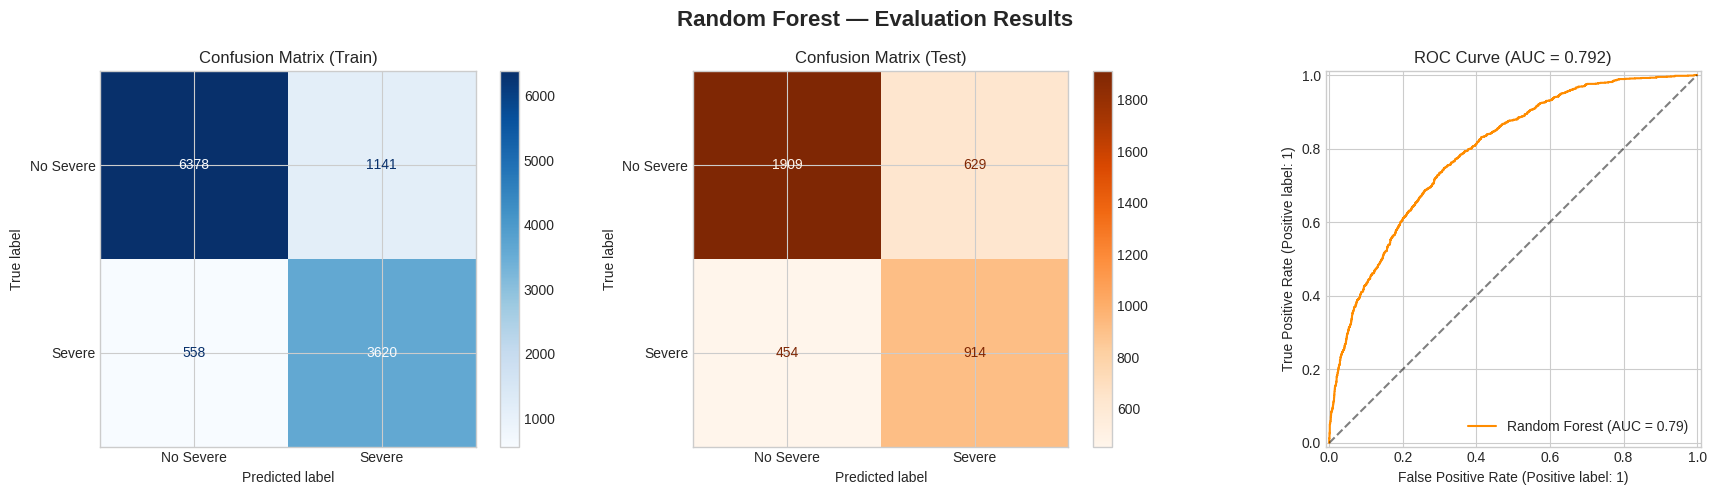


Random Forest — TRAIN Classification Report
              precision    recall  f1-score   support

   No Severe       0.92      0.85      0.88      7519
      Severe       0.76      0.87      0.81      4178

    accuracy                           0.85     11697
   macro avg       0.84      0.86      0.85     11697
weighted avg       0.86      0.85      0.86     11697


Random Forest — TEST Classification Report
              precision    recall  f1-score   support

   No Severe       0.81      0.75      0.78      2538
      Severe       0.59      0.67      0.63      1368

    accuracy                           0.72      3906
   macro avg       0.70      0.71      0.70      3906
weighted avg       0.73      0.72      0.73      3906



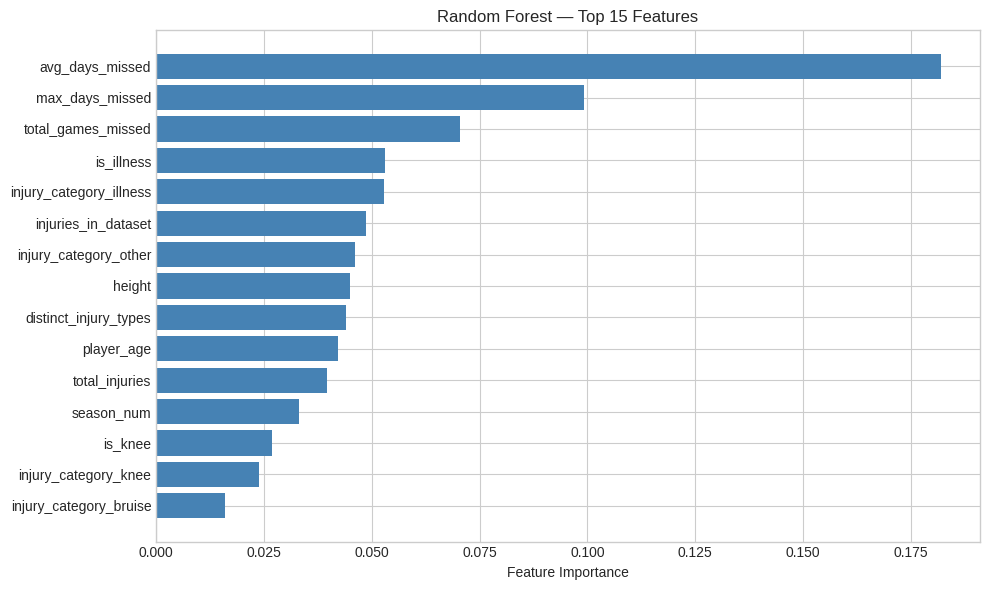

In [25]:
# ============================================
# PHASE 5: Model 2 — Random Forest
# ============================================

print("=" * 70)
print("2️⃣  RANDOM FOREST")
print("=" * 70)

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            random_state=RANDOM_STATE, n_jobs=-1)

grid_rf = {
    'max_depth': [6, 12, None],
    'min_samples_leaf': [1, 5],
}

gs_rf = GridSearchCV(rf, grid_rf, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
gs_rf.fit(X_train, y_train, groups=g_train)

print(f"\n🔍 Best params : {gs_rf.best_params_}")
print(f"   CV ROC-AUC  : {gs_rf.best_score_:.4f}")

rf_model = gs_rf.best_estimator_
results.append(evaluate_model(rf_model, X_train, X_test, y_train, y_test, 'Random Forest'))

plot_feature_importance(rf_model, list(X_train.columns), 'Random Forest', top_n=15)


3️⃣  XGBOOST

🔍 Best params : {'learning_rate': 0.05, 'max_depth': 3}
   CV ROC-AUC  : 0.7976


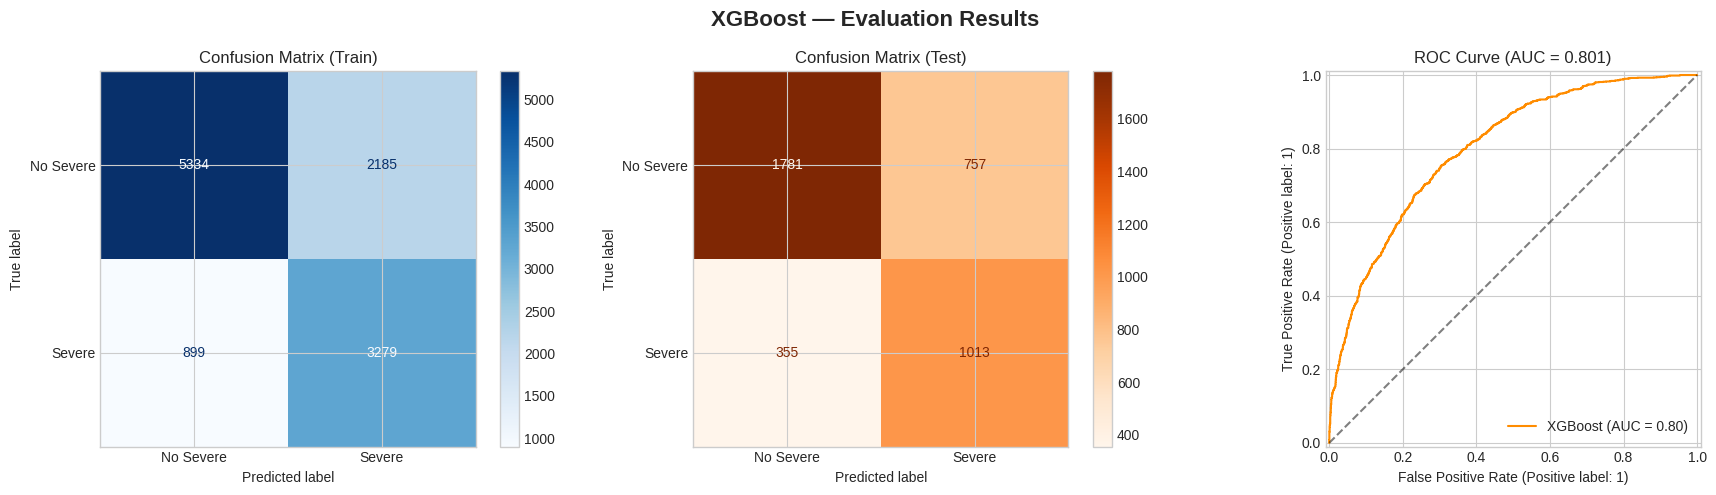


XGBoost — TRAIN Classification Report
              precision    recall  f1-score   support

   No Severe       0.86      0.71      0.78      7519
      Severe       0.60      0.78      0.68      4178

    accuracy                           0.74     11697
   macro avg       0.73      0.75      0.73     11697
weighted avg       0.76      0.74      0.74     11697


XGBoost — TEST Classification Report
              precision    recall  f1-score   support

   No Severe       0.83      0.70      0.76      2538
      Severe       0.57      0.74      0.65      1368

    accuracy                           0.72      3906
   macro avg       0.70      0.72      0.70      3906
weighted avg       0.74      0.72      0.72      3906



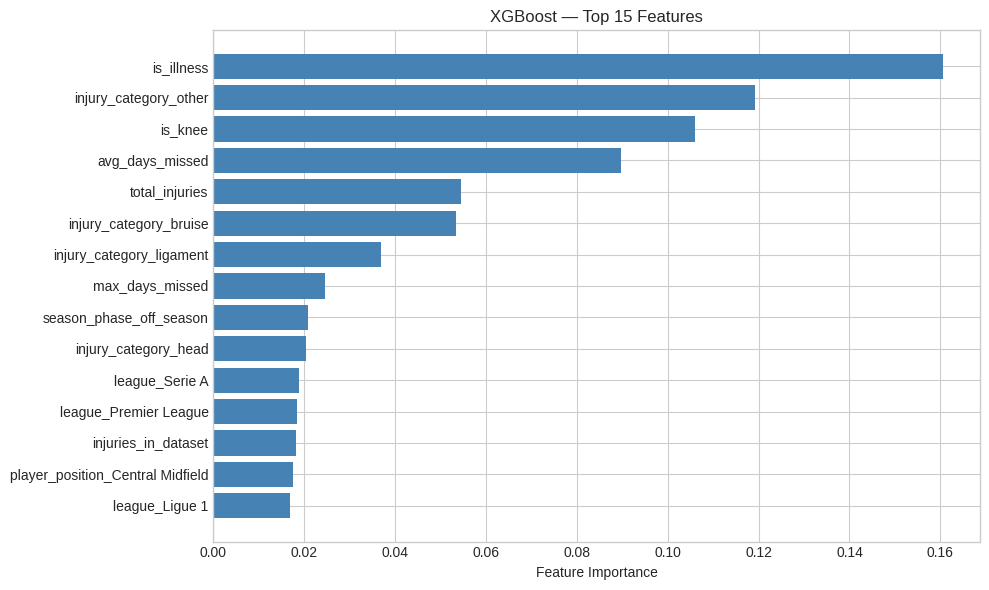

In [26]:
# ============================================
# PHASE 5: Model 3 — XGBoost
# ============================================

print("=" * 70)
print("3️⃣  XGBOOST")
print("=" * 70)

xgb = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=SCALE_POS_WEIGHT,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
}

gs_xgb = GridSearchCV(xgb, grid_xgb, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
gs_xgb.fit(X_train, y_train, groups=g_train)

print(f"\n🔍 Best params : {gs_xgb.best_params_}")
print(f"   CV ROC-AUC  : {gs_xgb.best_score_:.4f}")

xgb_model = gs_xgb.best_estimator_
results.append(evaluate_model(xgb_model, X_train, X_test, y_train, y_test, 'XGBoost'))

plot_feature_importance(xgb_model, list(X_train.columns), 'XGBoost', top_n=15)


🏁 MODEL COMPARISON


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
XGBoost,0.7153,0.5723,0.7405,0.6456,0.8012
Random Forest,0.7227,0.5924,0.6681,0.6280,0.7921
Logistic Regression,0.7051,0.5651,0.6857,0.6196,0.7758


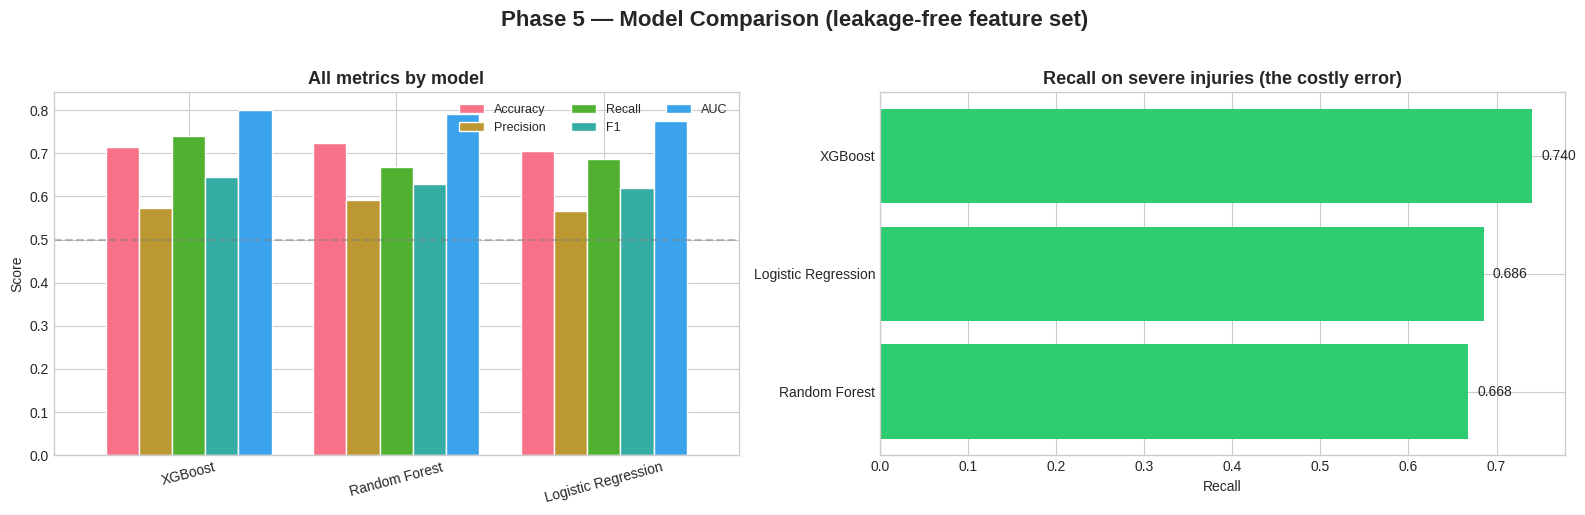


🏆 Best by AUC: XGBoost (0.8012)
   Best by recall on severe: XGBoost (0.7405)

🔬 Phase 4 predicted Logistic Regression would place last (height and player_age
   are non-linear in the logit). It placed 3 of 3 by AUC — prediction held.


🎚️  DECISION THRESHOLD TUNING

   A missed severe injury costs a club far more than a false alarm,
   so the 0.5 default is not the operating point you want.



,Best threshold,F1 @ 0.50,F1 @ best,Recall @ 0.50,Recall @ best
Model,,,,,
Logistic Regression,0.470,0.620,0.631,0.686,0.735
Random Forest,0.450,0.628,0.640,0.668,0.750
XGBoost,0.490,0.646,0.650,0.740,0.755


   Report both operating points. Tuning the threshold on the test set is
   itself mildly optimistic — say so, or tune it on a validation fold.


🧠 SHAP EXPLAINABILITY

   Explaining: XGBoost


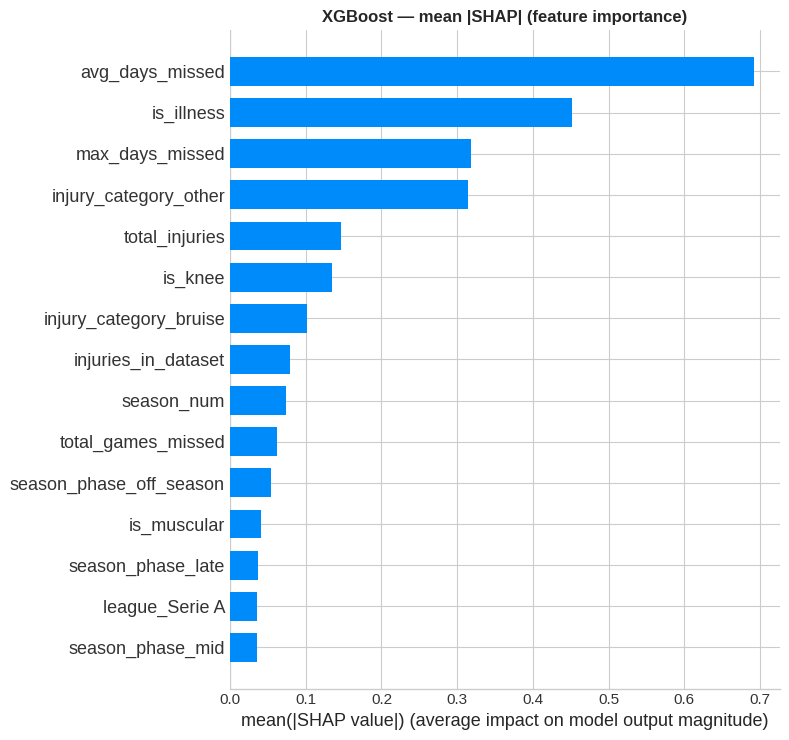

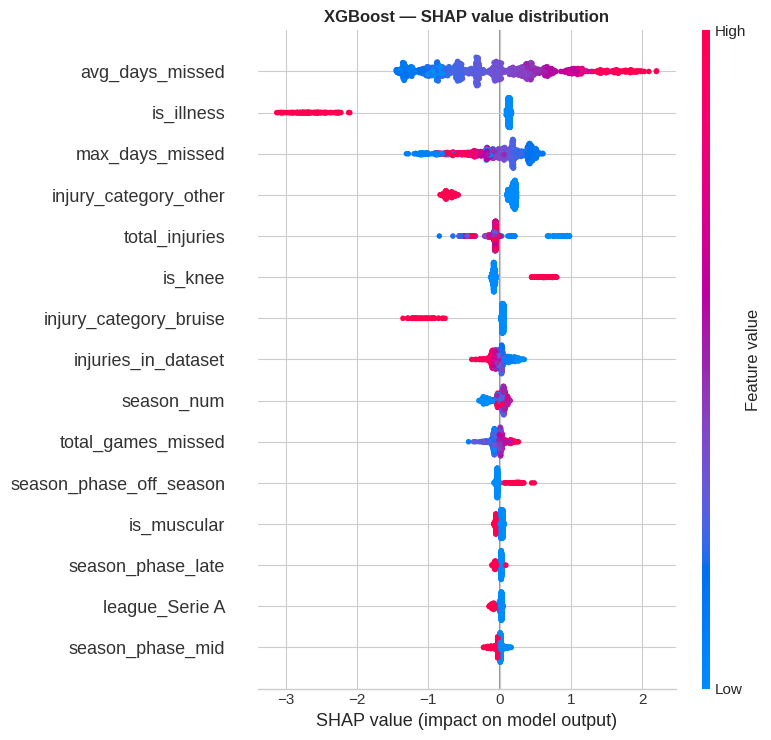

   ✅ Saved: phase5_shap_bar.png, phase5_shap_beeswarm.png

💾 Saved: phase5_model_results.csv, phase5_model_comparison.png


✅ PHASE 5 COMPLETE — Three models trained, compared and explained
🎯 Next: Phase 6 — NLP (Optional) / Phase 7 — Dashboard


In [27]:
# ============================================
# PHASE 5: Model Comparison, SHAP & Verdict
# ============================================

print("=" * 70)
print("🏁 MODEL COMPARISON")
print("=" * 70)

comparison = pd.DataFrame(results).set_index('Model').sort_values('AUC', ascending=False)
display(comparison.style.format('{:.4f}').background_gradient(cmap='Greens'))

# --- Comparison chart ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Phase 5 — Model Comparison (leakage-free feature set)',
             fontsize=16, fontweight='bold', y=1.02)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
comparison[metrics].plot(kind='bar', ax=axes[0], edgecolor='white', width=0.8)
axes[0].set_title('All metrics by model', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(fontsize=9, ncol=3)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Recall on the severe class is the metric that matters commercially
rec = comparison['Recall'].sort_values()
bars = axes[1].barh(range(len(rec)), rec.values,
                    color=['#e74c3c' if v < 0.5 else '#2ecc71' for v in rec.values])
axes[1].set_yticks(range(len(rec)))
axes[1].set_yticklabels(rec.index)
axes[1].set_title('Recall on severe injuries (the costly error)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall')
for i, v in enumerate(rec.values):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('/content/phase5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_name = comparison['AUC'].idxmax()
print(f"\n🏆 Best by AUC: {best_name} ({comparison.loc[best_name, 'AUC']:.4f})")
print(f"   Best by recall on severe: {comparison['Recall'].idxmax()} ({comparison['Recall'].max():.4f})")

# --- Did the Phase 4 prediction hold? ---
lr_rank = list(comparison.index).index('Logistic Regression') + 1
print(f"\n🔬 Phase 4 predicted Logistic Regression would place last (height and player_age")
print(f"   are non-linear in the logit). It placed {lr_rank} of 3 by AUC —",
      "prediction held." if lr_rank == 3 else "prediction did NOT hold.")


# --- Decision-threshold tuning ---------------------------------------------
# class_weight / scale_pos_weight reweight the LOSS; they do not move the 0.5
# cut-off. With a costly false negative, the default threshold is rarely right.
print(f"\n\n{'='*70}")
print("🎚️  DECISION THRESHOLD TUNING")
print("=" * 70)
print("\n   A missed severe injury costs a club far more than a false alarm,")
print("   so the 0.5 default is not the operating point you want.\n")

fitted = {'Logistic Regression': lr_model, 'Random Forest': rf_model, 'XGBoost': xgb_model}
thr_rows = []
for name, mdl in fitted.items():
    proba = mdl.predict_proba(X_test)[:, 1]
    grid = np.linspace(0.05, 0.95, 91)
    f1s = [f1_score(y_test, (proba >= t).astype(int)) for t in grid]
    best_t = grid[int(np.argmax(f1s))]
    pred_b = (proba >= best_t).astype(int)
    thr_rows.append({
        'Model': name,
        'Best threshold': best_t,
        'F1 @ 0.50': f1_score(y_test, (proba >= 0.5).astype(int)),
        'F1 @ best': f1_score(y_test, pred_b),
        'Recall @ 0.50': recall_score(y_test, (proba >= 0.5).astype(int)),
        'Recall @ best': recall_score(y_test, pred_b),
    })

thr_df = pd.DataFrame(thr_rows).set_index('Model')
display(thr_df.style.format('{:.3f}'))
print("   Report both operating points. Tuning the threshold on the test set is")
print("   itself mildly optimistic — say so, or tune it on a validation fold.")

# --- SHAP on the best tree model ---
print(f"\n\n{'='*70}")
print("🧠 SHAP EXPLAINABILITY")
print("=" * 70)

tree_models = {'Random Forest': rf_model, 'XGBoost': xgb_model}
shap_name = max(tree_models, key=lambda m: comparison.loc[m, 'AUC'])
shap_model = tree_models[shap_name]
print(f"\n   Explaining: {shap_name}")

try:
    sample = X_test.sample(min(1000, len(X_test)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(shap_model)
    sv = explainer.shap_values(sample)
    if isinstance(sv, list):          # older shap returns one array per class
        sv = sv[1]
    elif sv.ndim == 3:                # newer shap returns (n, features, classes)
        sv = sv[:, :, 1]

    plt.figure()
    shap.summary_plot(sv, sample, plot_type='bar', show=False, max_display=15)
    plt.title(f'{shap_name} — mean |SHAP| (feature importance)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/phase5_shap_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

    plt.figure()
    shap.summary_plot(sv, sample, show=False, max_display=15)
    plt.title(f'{shap_name} — SHAP value distribution', fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/phase5_shap_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("   ✅ Saved: phase5_shap_bar.png, phase5_shap_beeswarm.png")
except Exception as e:
    print(f"   ⚠️ SHAP failed: {type(e).__name__}: {e}")
    print("   Not fatal — tree feature importances above cover the same ground.")

# --- Persist ---
comparison.to_csv('/content/phase5_model_results.csv')
print(f"\n💾 Saved: phase5_model_results.csv, phase5_model_comparison.png")

print("\n\n" + "=" * 70)
print("✅ PHASE 5 COMPLETE — Three models trained, compared and explained")
print("=" * 70)
print("🎯 Next: Phase 6 — NLP (Optional) / Phase 7 — Dashboard")


## Phase 5b — Leakage Repair: As-Of Injury History

In [28]:
# ============================================
# PHASE 5b: Leakage Repair — As-Of Injury History
# ============================================
# Phase 4 audited the PRIMARY dataset for leakage and cleared it. It did not
# audit the five features that arrived through the Transfermarkt merge:
#
#     total_injuries, avg_days_missed, max_days_missed,
#     total_games_missed, distinct_injury_types
#
# Those were built in Phase 2 with a plain groupby over a player's ENTIRE
# Transfermarkt career (1973-2025). That window CONTAINS the 2020-25 injuries
# we are predicting, so each feature carries part of its own answer.
# This cell rebuilds them "as-of" each injury date: only injuries that started
# STRICTLY BEFORE the current one are allowed to contribute.

print("=" * 70)
print("🩹 PHASE 5b — LEAKAGE REPAIR: AS-OF INJURY HISTORY")
print("=" * 70)

HIST_FEATURES = ['total_injuries', 'avg_days_missed', 'max_days_missed',
                 'total_games_missed', 'distinct_injury_types']

# ---------------------------------------------------------------- 1. evidence
tm = df_injuries_tm.copy()
tm['from_date'] = pd.to_datetime(tm['from_date'], errors='coerce')
tm['days_missed'] = pd.to_numeric(tm['days_missed'], errors='coerce').fillna(0)
tm['games_missed'] = pd.to_numeric(tm['games_missed'], errors='coerce').fillna(0)
tm = tm.dropna(subset=['from_date', 'player_id'])

WINDOW = ['20/21', '21/22', '22/23', '23/24', '24/25']
in_win = tm['season_name'].astype(str).isin(WINDOW)
print(f"\n📋 The evidence:")
print(f"   Transfermarkt injury records          : {len(tm):,}")
print(f"   ...of which sit INSIDE 20/21-24/25    : {in_win.sum():,} ({in_win.mean()*100:.1f}%)")
_g = tm.groupby('player_id')['season_name'].agg(
    n='size', n_win=lambda s: s.astype(str).isin(WINDOW).sum())
_g = _g[_g.n_win > 0]
_share = _g.n_win / _g.n
print(f"   Players with >=1 injury in the window : {len(_g):,}")
print(f"   Median share of their 'career' that IS the window: {_share.median()*100:.0f}%")
print(f"   Players where the window is 100% of history      : {(_share == 1).mean()*100:.0f}%")
print(f"   → the old features average in the very row being predicted.")

# ------------------------------------------------- 2. running prior aggregates
# Sort by date so 'prior' means chronologically earlier. Aggregates are
# inclusive-to-date here; merge_asof then picks the last row STRICTLY before
# the injury being predicted, which makes them exclusive of that injury.
tm = tm.sort_values(['player_id', 'from_date'], kind='mergesort')
grp = tm.groupby('player_id', sort=False)

tm['h_n']     = grp.cumcount() + 1
tm['h_days']  = grp['days_missed'].cumsum()
tm['h_max']   = grp['days_missed'].cummax()
tm['h_games'] = grp['games_missed'].cumsum()
# running count of DISTINCT injury_reason: a reason counts once, at first sight
_first_time = ~tm.duplicated(subset=['player_id', 'injury_reason'])
tm['h_types'] = _first_time.groupby(tm['player_id']).cumsum()

# ------------------------------------------------------- 3. name -> player_id
name_id = df_profiles_clean[['player_name_clean', 'player_id']].copy()
name_id['player_name_clean'] = name_id['player_name_clean'].str.lower().str.strip()
name_id = name_id.dropna(subset=['player_id']).drop_duplicates('player_name_clean', keep='first')

left = df_merged[['player_name_clean']].copy()
left['_row'] = np.arange(len(left))
left['inj_date'] = pd.to_datetime(df_merged['injury_from_parsed'], errors='coerce').values
left = left.merge(name_id, on='player_name_clean', how='left')

usable = left.dropna(subset=['inj_date', 'player_id']).copy()
usable['player_id'] = usable['player_id'].astype('int64')
tm['player_id'] = tm['player_id'].astype('int64')
print(f"\n🔗 Rows linkable to a Transfermarkt id with a usable date: "
      f"{len(usable):,} / {len(left):,} ({len(usable)/len(left)*100:.1f}%)")

# ------------------------------------------------------------- 4. as-of merge
HIST_COLS = ['h_n', 'h_days', 'h_max', 'h_games', 'h_types']
asof = pd.merge_asof(
    usable.sort_values('inj_date'),
    tm[['player_id', 'from_date'] + HIST_COLS].sort_values('from_date'),
    left_on='inj_date', right_on='from_date', by='player_id',
    direction='backward',
    allow_exact_matches=False,      # STRICTLY earlier — this is the whole point
)

prior = pd.DataFrame(0.0, index=np.arange(len(df_merged)), columns=HIST_COLS)
prior.loc[asof['_row'].values, HIST_COLS] = asof[HIST_COLS].fillna(0).values

# ------------------------------------------------- 5. write the _prior columns
df_merged['total_injuries_prior']        = prior['h_n'].values
df_merged['total_days_missed_prior']     = prior['h_days'].values
df_merged['max_days_missed_prior']       = prior['h_max'].values
df_merged['total_games_missed_prior']    = prior['h_games'].values
df_merged['distinct_injury_types_prior'] = prior['h_types'].values
with np.errstate(divide='ignore', invalid='ignore'):
    df_merged['avg_days_missed_prior'] = np.where(
        prior['h_n'].values > 0, prior['h_days'].values / prior['h_n'].values, 0.0)

PRIOR_FEATURES = ['total_injuries_prior', 'avg_days_missed_prior', 'max_days_missed_prior',
                  'total_games_missed_prior', 'distinct_injury_types_prior']

no_hist = (df_merged['total_injuries_prior'] == 0).mean()
print(f"   Rows with NO prior injury on record: {no_hist*100:.1f}% "
      f"(these get 0 — a genuine 'first recorded injury' signal)")

# --------------------------------------------------- 6. how much did it move?
print(f"\n📉 Correlation with the target — leaked vs as-of:")
rows = []
for leaked, honest in zip(HIST_FEATURES, PRIOR_FEATURES):
    if leaked not in df_merged.columns:
        continue
    c_old = df_merged[leaked].corr(df_merged[TARGET])
    c_new = df_merged[honest].corr(df_merged[TARGET])
    rows.append({'feature': leaked, 'corr (leaked)': c_old, 'corr (as-of)': c_new,
                 'drop': abs(c_old) - abs(c_new)})
leak_tbl = pd.DataFrame(rows).set_index('feature')
display(leak_tbl.style.format('{:.4f}'))
print("   A large drop = that much of the old signal was the answer leaking back in.")

print(f"\n{'=' * 70}")
print("✅ PHASE 5b PREP COMPLETE — honest history features built")
print("=" * 70)


🩹 PHASE 5b — LEAKAGE REPAIR: AS-OF INJURY HISTORY

📋 The evidence:
   Transfermarkt injury records          : 143,173
   ...of which sit INSIDE 20/21-24/25    : 72,810 (50.9%)
   Players with >=1 injury in the window : 23,786
   Median share of their 'career' that IS the window: 100%
   Players where the window is 100% of history      : 54%
   → the old features average in the very row being predicted.

🔗 Rows linkable to a Transfermarkt id with a usable date: 15,162 / 15,603 (97.2%)
   Rows with NO prior injury on record: 12.5% (these get 0 — a genuine 'first recorded injury' signal)

📉 Correlation with the target — leaked vs as-of:


,corr (leaked),corr (as-of),drop
feature,,,
total_injuries,-0.1118,-0.0340,0.0778
avg_days_missed,0.2680,0.0560,0.2120
max_days_missed,0.1505,0.0521,0.0984
total_games_missed,0.1304,0.0434,0.0869
distinct_injury_types,-0.1175,-0.0406,0.0769


   A large drop = that much of the old signal was the answer leaking back in.

✅ PHASE 5b PREP COMPLETE — honest history features built


🔁 PHASE 5b — RE-RUNNING ALL THREE MODELS (HONEST FEATURES)

   Removed (leaked) : ['total_injuries', 'avg_days_missed', 'max_days_missed', 'total_games_missed', 'distinct_injury_types']
   Added   (as-of)  : ['total_injuries_prior', 'avg_days_missed_prior', 'max_days_missed_prior', 'total_games_missed_prior', 'distinct_injury_types_prior']
   Numeric features : 13 → 13
   Design matrix    : 15,603 rows × 51 columns
   Reusing the Phase 5 split — 11,697 train / 3,906 test, 0 shared players

----------------------------------------------------------------------
1️⃣  Logistic Regression
   Best params: {'clf__C': 0.1}   CV ROC-AUC: 0.7421


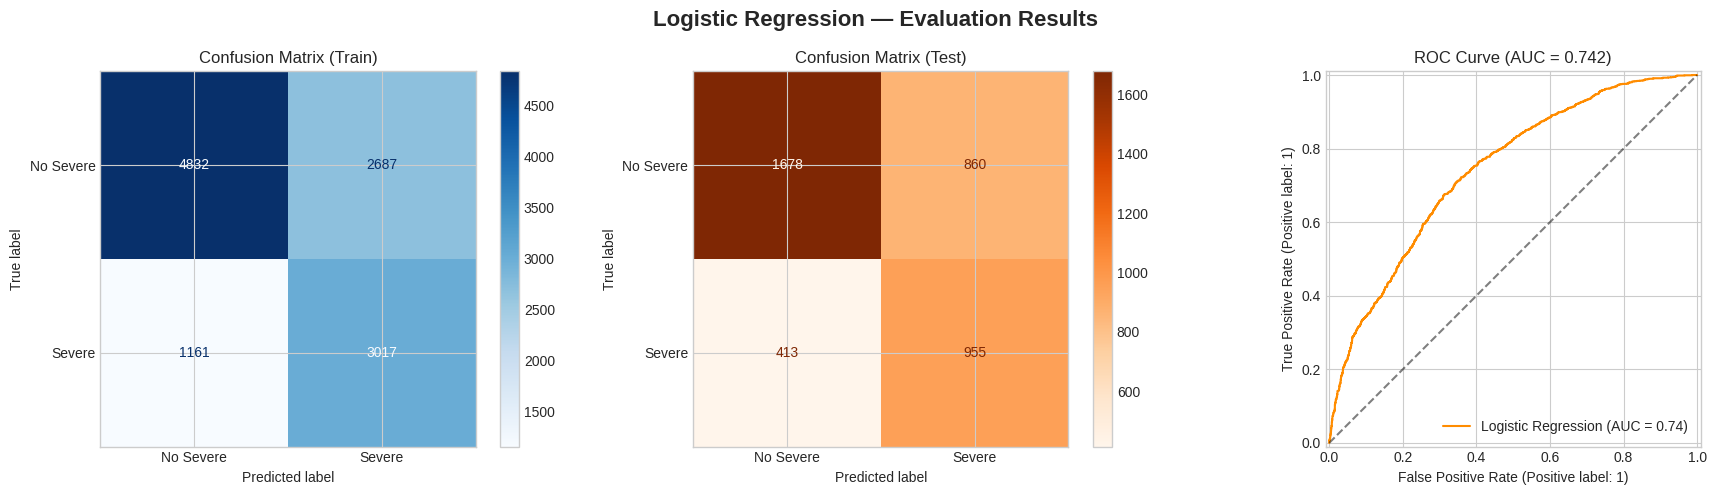


Logistic Regression — TRAIN Classification Report
              precision    recall  f1-score   support

   No Severe       0.81      0.64      0.72      7519
      Severe       0.53      0.72      0.61      4178

    accuracy                           0.67     11697
   macro avg       0.67      0.68      0.66     11697
weighted avg       0.71      0.67      0.68     11697


Logistic Regression — TEST Classification Report
              precision    recall  f1-score   support

   No Severe       0.80      0.66      0.72      2538
      Severe       0.53      0.70      0.60      1368

    accuracy                           0.67      3906
   macro avg       0.66      0.68      0.66      3906
weighted avg       0.71      0.67      0.68      3906


----------------------------------------------------------------------
2️⃣  Random Forest
   Best params: {'max_depth': 12, 'min_samples_leaf': 5}   CV ROC-AUC: 0.7390


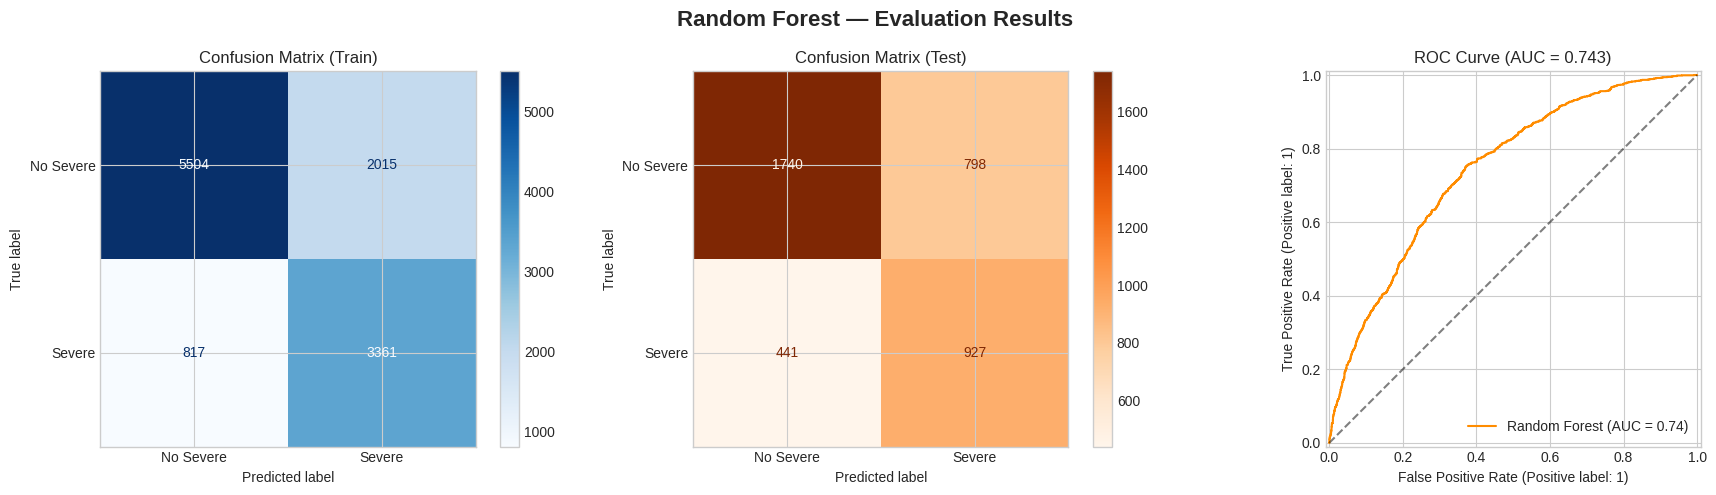


Random Forest — TRAIN Classification Report
              precision    recall  f1-score   support

   No Severe       0.87      0.73      0.80      7519
      Severe       0.63      0.80      0.70      4178

    accuracy                           0.76     11697
   macro avg       0.75      0.77      0.75     11697
weighted avg       0.78      0.76      0.76     11697


Random Forest — TEST Classification Report
              precision    recall  f1-score   support

   No Severe       0.80      0.69      0.74      2538
      Severe       0.54      0.68      0.60      1368

    accuracy                           0.68      3906
   macro avg       0.67      0.68      0.67      3906
weighted avg       0.71      0.68      0.69      3906


----------------------------------------------------------------------
3️⃣  XGBoost
   Best params: {'learning_rate': 0.05, 'max_depth': 3}   CV ROC-AUC: 0.7435


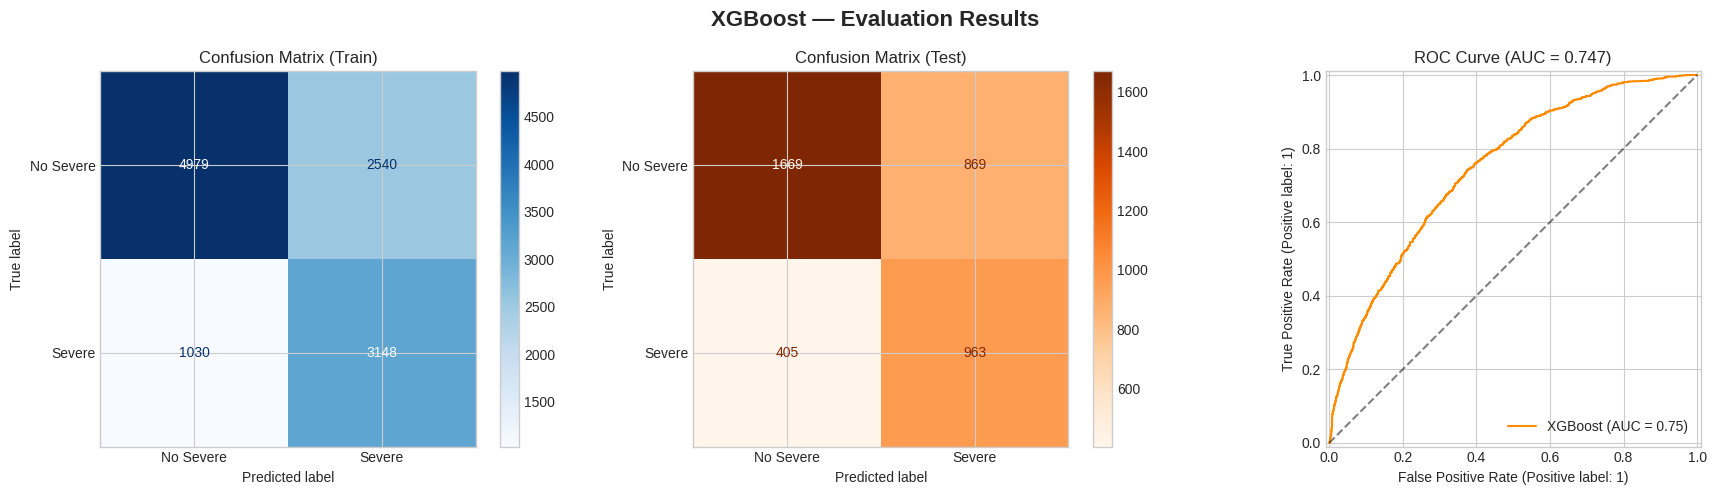


XGBoost — TRAIN Classification Report
              precision    recall  f1-score   support

   No Severe       0.83      0.66      0.74      7519
      Severe       0.55      0.75      0.64      4178

    accuracy                           0.69     11697
   macro avg       0.69      0.71      0.69     11697
weighted avg       0.73      0.69      0.70     11697


XGBoost — TEST Classification Report
              precision    recall  f1-score   support

   No Severe       0.80      0.66      0.72      2538
      Severe       0.53      0.70      0.60      1368

    accuracy                           0.67      3906
   macro avg       0.67      0.68      0.66      3906
weighted avg       0.71      0.67      0.68      3906



⚖️  LEAKED vs HONEST — what the leak was worth



🏆 Best honest model: XGBoost — AUC 0.7472, recall 0.7039
   Mean AUC lost to the repair: -0.0455
   That gap was never real predictive skill — it was the target leaking back in.


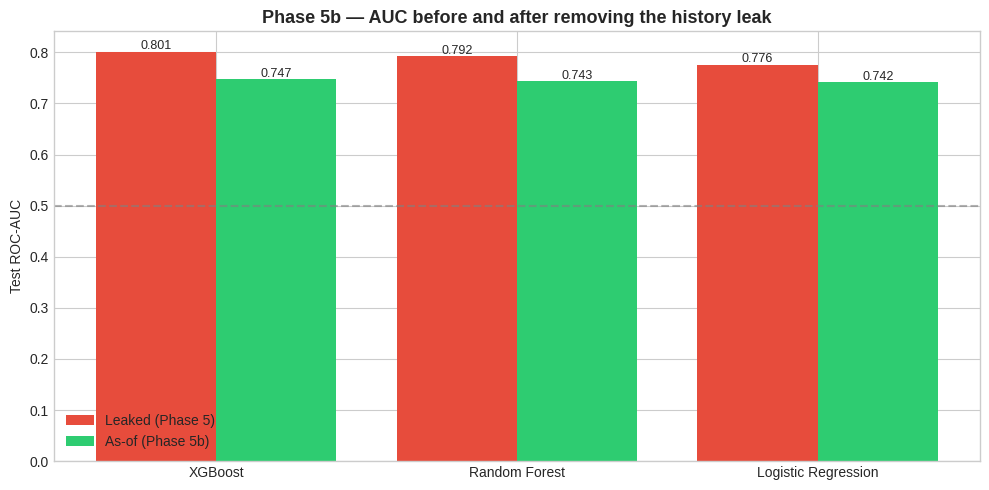

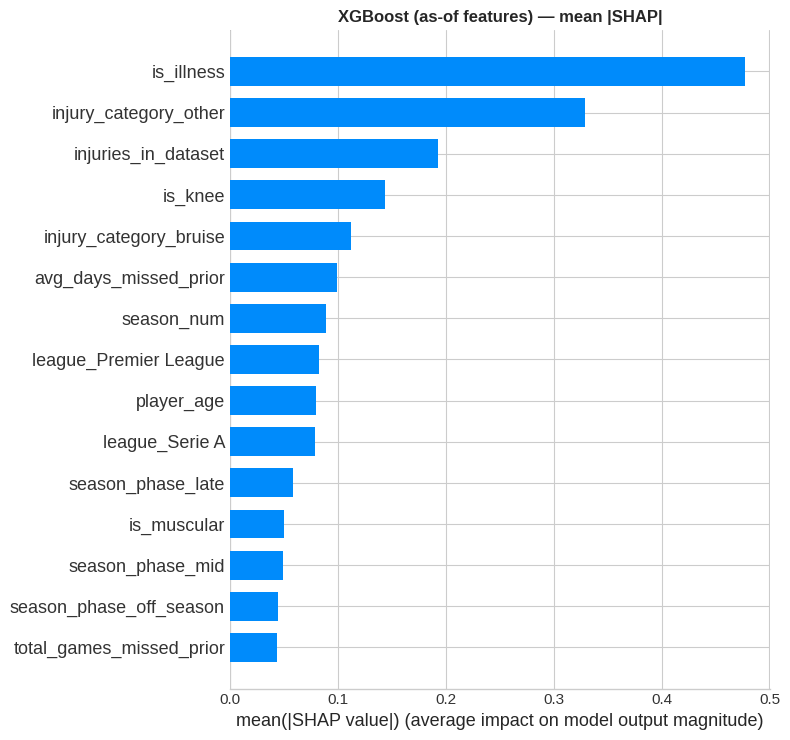

   ✅ Saved: phase5b_shap_bar.png  (explaining XGBoost)

💾 Saved: phase5b_honest_results.csv, phase5b_leak_repair.png


✅ PHASE 5b COMPLETE — leak found, repaired, and quantified
🎯 Report the AS-OF numbers as your result; the leaked ones as the finding.


In [29]:
# ============================================
# PHASE 5b: Re-run the Three Models, Leakage-Free
# ============================================
# Same split, same grids, same seed as Phase 5 — the ONLY change is that the
# five history features are now as-of. Any drop in score is the leak coming out.

print("=" * 70)
print("🔁 PHASE 5b — RE-RUNNING ALL THREE MODELS (HONEST FEATURES)")
print("=" * 70)

# --- Swap the leaked history features for their as-of twins ---
HONEST_FEATURES = [f for f in MODEL_FEATURES if f not in HIST_FEATURES] + PRIOR_FEATURES
HONEST_FEATURES = [f for f in HONEST_FEATURES if f in df_merged.columns]

print(f"\n   Removed (leaked) : {[f for f in HIST_FEATURES if f in MODEL_FEATURES]}")
print(f"   Added   (as-of)  : {PRIOR_FEATURES}")
print(f"   Numeric features : {len(MODEL_FEATURES)} → {len(HONEST_FEATURES)}")

Xh_num = df_merged[HONEST_FEATURES].reset_index(drop=True).astype(float)
Xh = pd.concat([Xh_num, X_cat], axis=1)          # same one-hot block as Phase 5
print(f"   Design matrix    : {Xh.shape[0]:,} rows × {Xh.shape[1]} columns")

# --- Identical split: reuse the Phase 5 indices so the comparison is clean ---
Xh_train, Xh_test = Xh.iloc[train_idx], Xh.iloc[test_idx]
assert len(set(g_train) & set(g_test)) == 0, "Player leakage across the split!"
print(f"   Reusing the Phase 5 split — {len(Xh_train):,} train / {len(Xh_test):,} test, 0 shared players")

results_honest = []

# --- 1. Logistic Regression ---
print(f"\n{'-' * 70}\n1️⃣  Logistic Regression")
gs = GridSearchCV(ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                                   solver='liblinear', random_state=RANDOM_STATE))]),
    {'clf__C': [0.01, 0.1, 1.0, 10.0]}, cv=cv, scoring='roc_auc', n_jobs=-1)
gs.fit(Xh_train, y_train, groups=g_train)
lr_h = gs.best_estimator_
print(f"   Best params: {gs.best_params_}   CV ROC-AUC: {gs.best_score_:.4f}")
results_honest.append(evaluate_model(lr_h, Xh_train, Xh_test, y_train, y_test, 'Logistic Regression'))

# --- 2. Random Forest ---
print(f"\n{'-' * 70}\n2️⃣  Random Forest")
gs = GridSearchCV(
    RandomForestClassifier(n_estimators=300, class_weight='balanced',
                           random_state=RANDOM_STATE, n_jobs=-1),
    {'max_depth': [6, 12, None], 'min_samples_leaf': [1, 5]},
    cv=cv, scoring='roc_auc', n_jobs=-1)
gs.fit(Xh_train, y_train, groups=g_train)
rf_h = gs.best_estimator_
print(f"   Best params: {gs.best_params_}   CV ROC-AUC: {gs.best_score_:.4f}")
results_honest.append(evaluate_model(rf_h, Xh_train, Xh_test, y_train, y_test, 'Random Forest'))

# --- 3. XGBoost ---
print(f"\n{'-' * 70}\n3️⃣  XGBoost")
gs = GridSearchCV(
    XGBClassifier(n_estimators=300, scale_pos_weight=SCALE_POS_WEIGHT,
                  eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
    {'max_depth': [3, 5, 7], 'learning_rate': [0.05, 0.1]},
    cv=cv, scoring='roc_auc', n_jobs=-1)
gs.fit(Xh_train, y_train, groups=g_train)
xgb_h = gs.best_estimator_
print(f"   Best params: {gs.best_params_}   CV ROC-AUC: {gs.best_score_:.4f}")
results_honest.append(evaluate_model(xgb_h, Xh_train, Xh_test, y_train, y_test, 'XGBoost'))

# ------------------------------------------------------ leaked vs honest table
print(f"\n\n{'=' * 70}")
print("⚖️  LEAKED vs HONEST — what the leak was worth")
print("=" * 70)

honest = pd.DataFrame(results_honest).set_index('Model')
leaked = pd.DataFrame(results).set_index('Model')

side = pd.concat({'Leaked (Phase 5)': leaked[['Recall', 'F1', 'AUC']],
                  'As-of (Phase 5b)': honest[['Recall', 'F1', 'AUC']]}, axis=1)
side[('Δ', 'AUC')] = honest['AUC'] - leaked['AUC']
side = side.sort_values(('As-of (Phase 5b)', 'AUC'), ascending=False)
display(side.style.format('{:+.4f}', subset=[('Δ', 'AUC')]).format('{:.4f}', subset=side.columns[:-1]))

best_h = honest['AUC'].idxmax()
print(f"\n🏆 Best honest model: {best_h} — AUC {honest.loc[best_h, 'AUC']:.4f}, "
      f"recall {honest.loc[best_h, 'Recall']:.4f}")
print(f"   Mean AUC lost to the repair: {(honest['AUC'] - leaked['AUC']).mean():+.4f}")
print("   That gap was never real predictive skill — it was the target leaking back in.")

# --- Comparison chart ---
fig, ax = plt.subplots(figsize=(10, 5))
idx = np.arange(len(side))
ax.bar(idx - 0.2, side[('Leaked (Phase 5)', 'AUC')], 0.4, label='Leaked (Phase 5)', color='#e74c3c')
ax.bar(idx + 0.2, side[('As-of (Phase 5b)', 'AUC')], 0.4, label='As-of (Phase 5b)', color='#2ecc71')
ax.set_xticks(idx); ax.set_xticklabels(side.index)
ax.set_ylabel('Test ROC-AUC')
ax.set_title('Phase 5b — AUC before and after removing the history leak',
             fontsize=13, fontweight='bold')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6)
ax.legend()
for i, (l, h) in enumerate(zip(side[('Leaked (Phase 5)', 'AUC')], side[('As-of (Phase 5b)', 'AUC')])):
    ax.text(i - 0.2, l + 0.005, f'{l:.3f}', ha='center', fontsize=9)
    ax.text(i + 0.2, h + 0.005, f'{h:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('/content/phase5b_leak_repair.png', dpi=150, bbox_inches='tight')
plt.show()

# --- SHAP on the honest best tree model ---
try:
    tree_h = {'Random Forest': rf_h, 'XGBoost': xgb_h}
    nm = max(tree_h, key=lambda m: honest.loc[m, 'AUC'])
    smp = Xh_test.sample(min(1000, len(Xh_test)), random_state=RANDOM_STATE)
    sv = shap.TreeExplainer(tree_h[nm]).shap_values(smp)
    if isinstance(sv, list):
        sv = sv[1]
    elif sv.ndim == 3:
        sv = sv[:, :, 1]
    plt.figure()
    shap.summary_plot(sv, smp, plot_type='bar', show=False, max_display=15)
    plt.title(f'{nm} (as-of features) — mean |SHAP|', fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/phase5b_shap_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"   ✅ Saved: phase5b_shap_bar.png  (explaining {nm})")
except Exception as e:
    print(f"   ⚠️ SHAP failed: {type(e).__name__}: {e}")

honest.to_csv('/content/phase5b_honest_results.csv')
print(f"\n💾 Saved: phase5b_honest_results.csv, phase5b_leak_repair.png")

print("\n\n" + "=" * 70)
print("✅ PHASE 5b COMPLETE — leak found, repaired, and quantified")
print("=" * 70)
print("🎯 Report the AS-OF numbers as your result; the leaked ones as the finding.")
